In [3]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report,confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 70.2 MB/s eta 0:00:00


In [12]:
df=pd.read_csv('/content/mice_final_data.csv')
cols=df.columns
df
df_normal=pd.read_csv('/content/df_normal.csv')
df

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-0.381981,-0.917519,2.905965,-0.914915,14.642069,-1.124235,2.249968,0.823538,1.574354,1
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,14.243738,-4.937284,0.089265,-4.937284,12.361204,3.886517,3.381750,5.827666,-0.056206,1
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,5.685728,-0.955917,0.871249,-0.955908,1.587669,1.665659,-0.052572,-0.597566,-2.745544,0
3,29.96,29.22,28.39,31.96,31.12,68.60,67.80,70.09,71.88,76.71,...,5.497906,-2.134062,-1.188985,-2.134062,4.550075,0.020477,3.230979,-0.032255,0.157905,0
4,30.09,29.58,28.06,30.46,28.84,78.24,67.31,72.63,77.78,74.76,...,7.259878,-0.192612,-1.648626,-0.192612,9.741397,0.979056,-0.516248,2.129390,0.020616,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16993,29.68,29.91,30.18,30.78,28.06,77.29,75.94,75.59,73.05,73.09,...,-6.240376,-1.627189,-0.384339,-1.627189,-1.251171,-0.972060,2.343462,-0.342200,1.252295,0
16994,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,-1.139003,2.228396,0.044608,2.228396,5.861357,0.414884,-1.108650,-0.813562,1.744824,1
16995,28.44,28.81,31.56,30.57,28.79,72.11,70.08,73.60,73.15,68.72,...,3.729189,-0.858941,0.124091,-0.859033,-0.722216,4.351513,0.000299,1.684467,-1.652202,0
16996,28.17,28.47,28.79,28.99,29.71,75.93,77.20,67.56,76.45,76.70,...,-1.567624,-2.373612,-0.820434,-2.373612,-5.930715,1.433596,-2.000998,4.125043,-0.552398,0


# 박스플롯

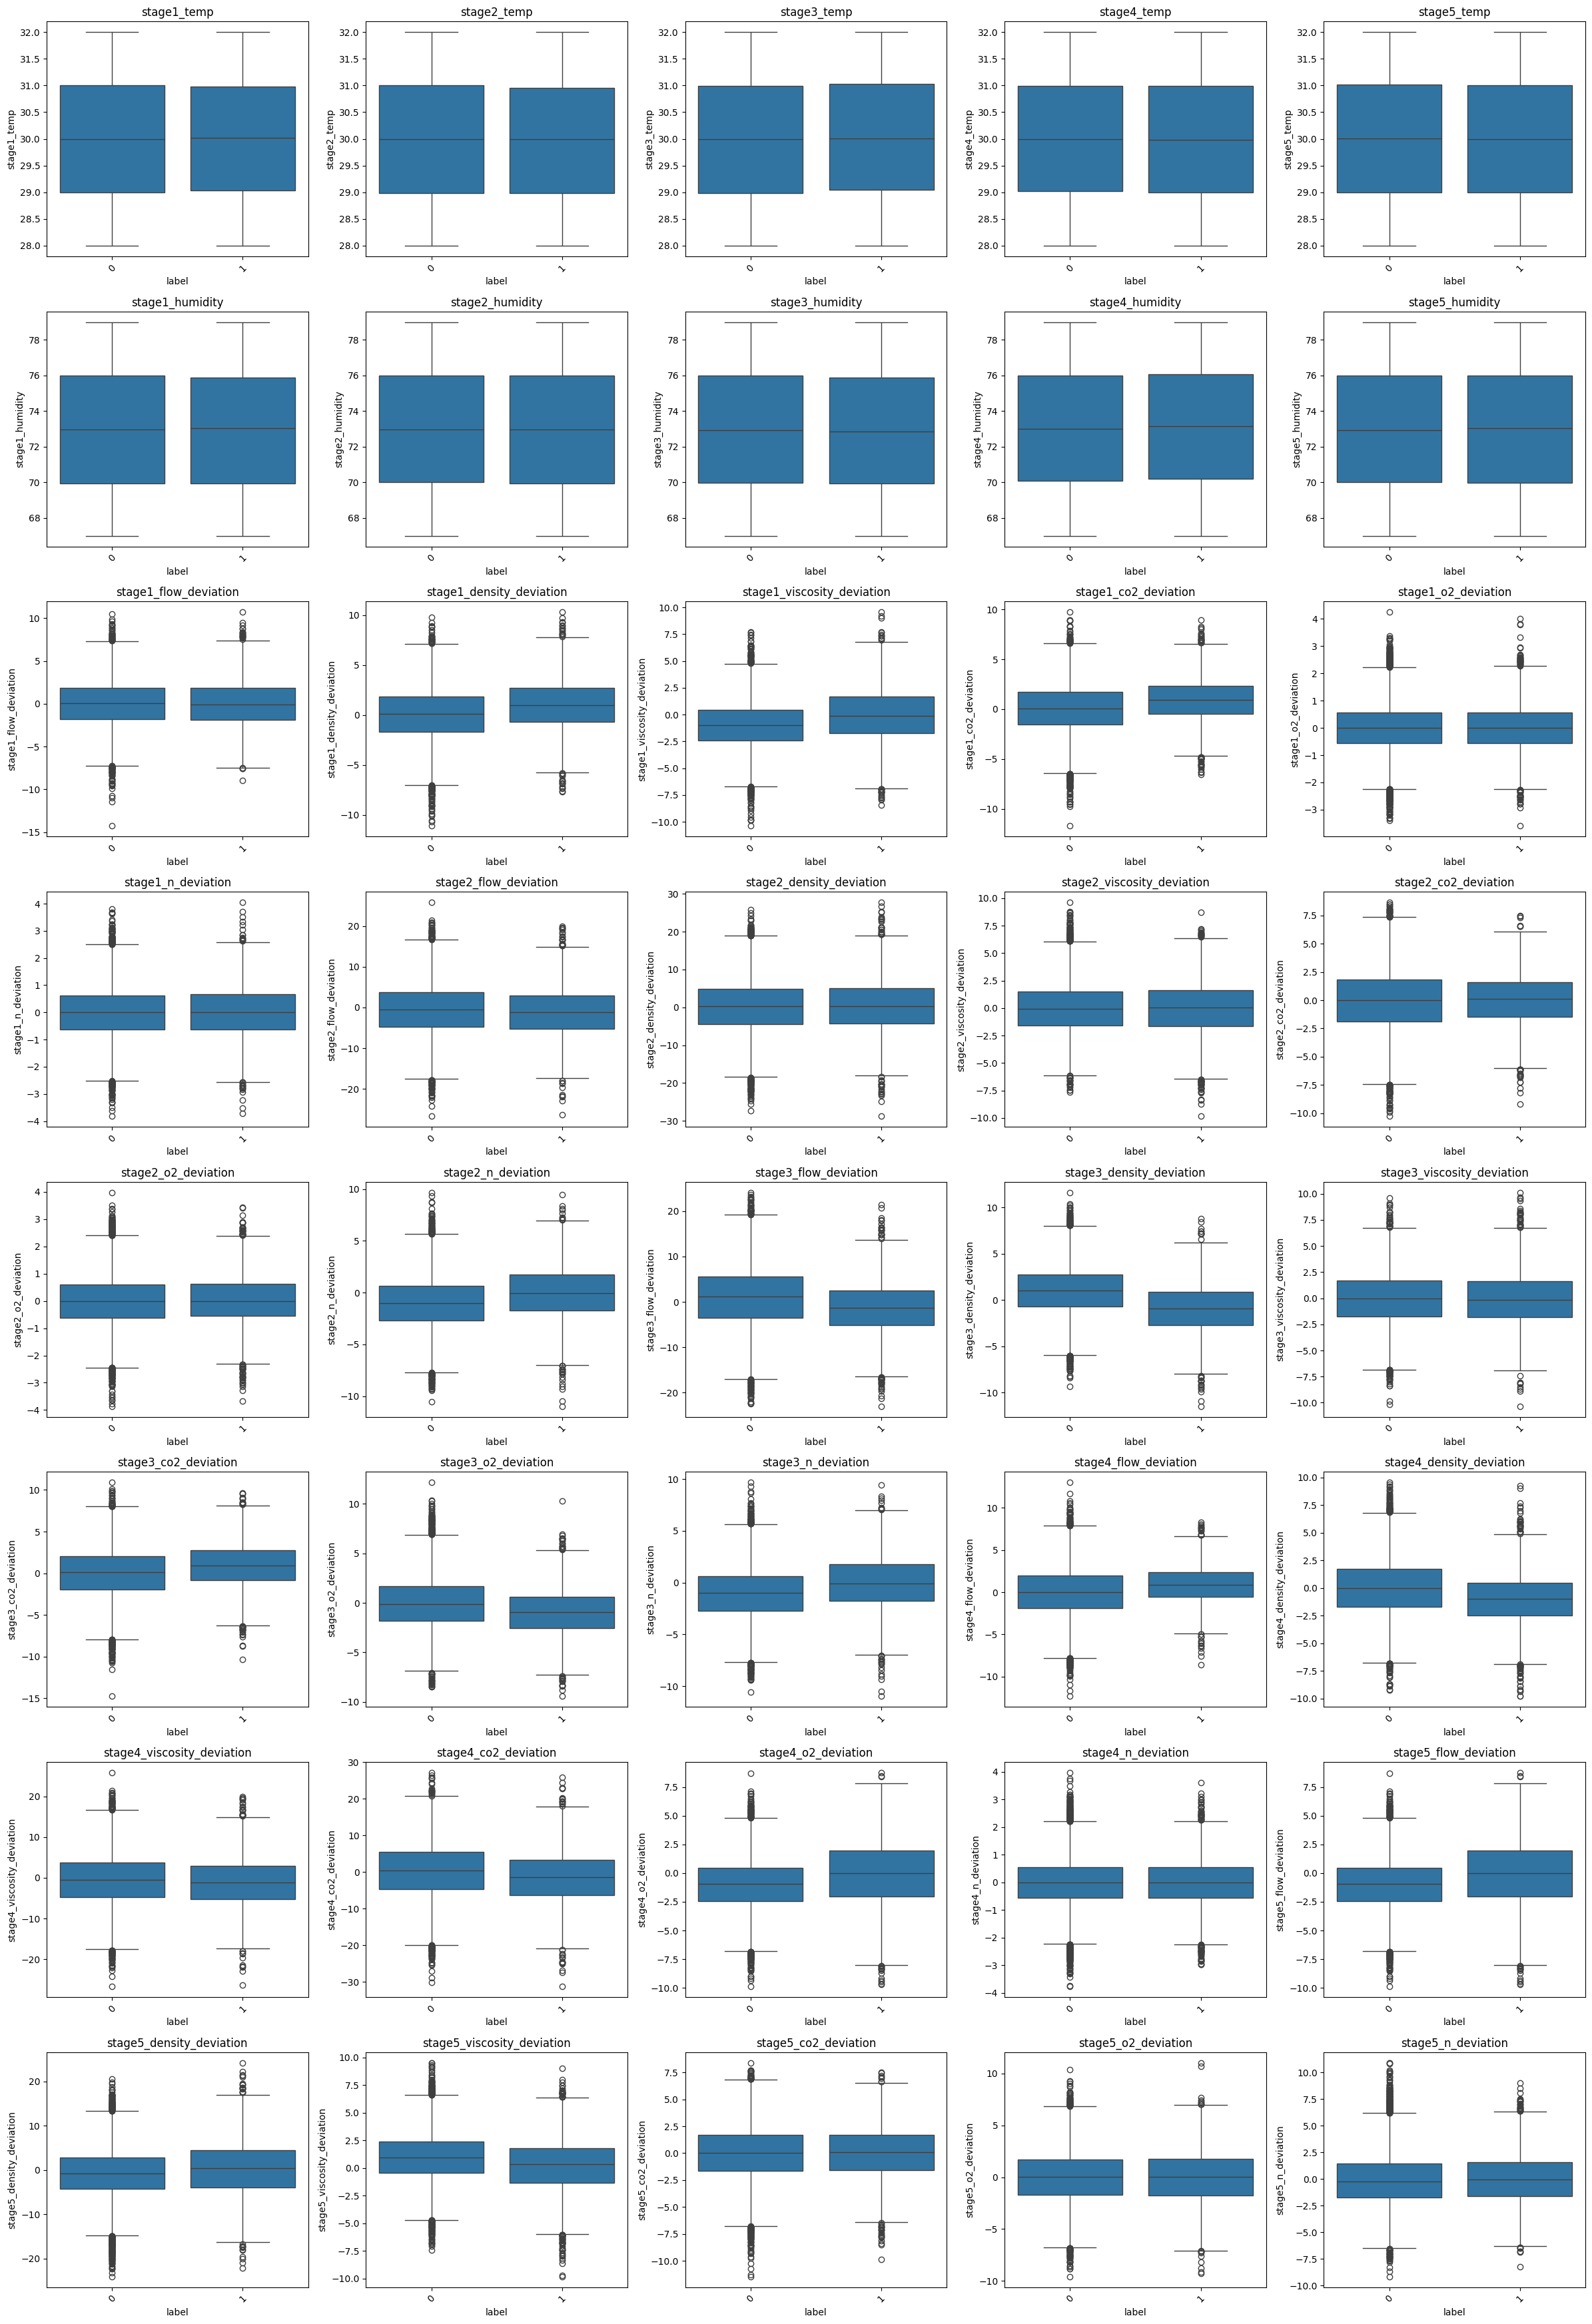

In [ ]:
features = df.columns[:-1]

fig, axes = plt.subplots(8, 5, figsize=(24, 35))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

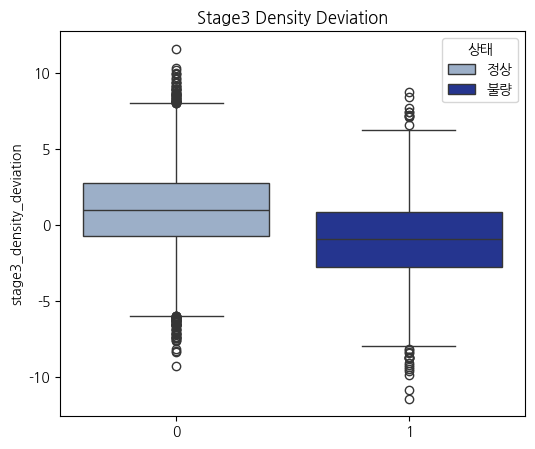

In [16]:
# label 컬럼을 정수형(int)으로 변환
df['label'] = df['label'].astype(int)

plt.figure(figsize=(6,5))

sns.boxplot(
    x='label',
    y='stage3_density_deviation',
    hue='label',
    data=df,
    palette={0:'#95aecf', 1:'#1428a0'}
)

plt.xlabel('')
plt.ylabel('stage3_density_deviation')
plt.title('Stage3 Density Deviation')
plt.legend(labels=['정상', '불량'],title='상태') # 이제 자동으로 0, 1이 나옵니다.

plt.show()

/tmp/ipykernel_1231/214491573.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect_ratio = df.groupby("bin")["label"].mean()


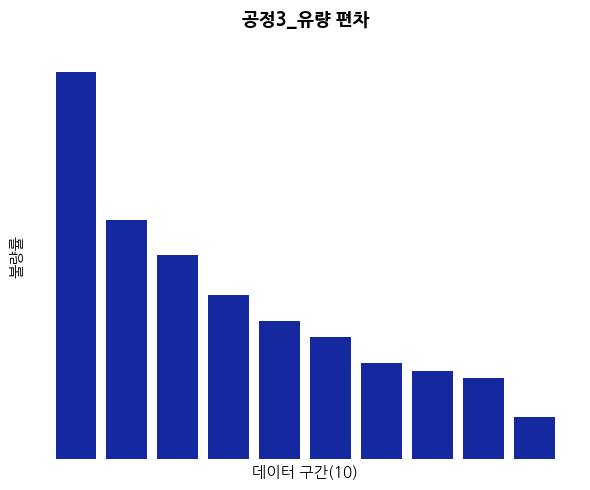

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 데이터 준비
target_col = "stage3_density_deviation"
df["bin"] = pd.qcut(df[target_col], q=10, duplicates='drop')
defect_ratio = df.groupby("bin")["label"].mean()

# 시각화 설정
plt.figure(figsize=(6, 5))

# 막대 그래프 (#4b6587 색상 적용)
plt.bar(range(len(defect_ratio)), defect_ratio, color='#1428a0', edgecolor='none')

# 축 제목 설정 (한국어 적용)
plt.title("공정3_유량 편차", fontsize=13, pad=20, fontweight='bold')
plt.xlabel("데이터 구간(10)", fontsize=11)
plt.ylabel("불량률", fontsize=11)

# 눈금 및 테두리 제거
plt.xticks([])
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/3584501141.py:36: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout

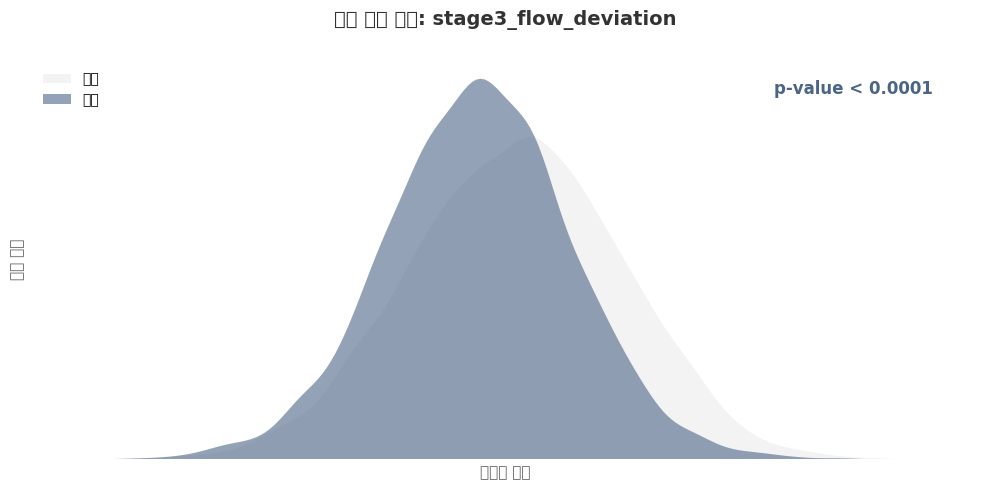

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 데이터 준비 및 t-test 계산
target_col = "stage3_flow_deviation"
group0 = df[df['label'] == 0][target_col].dropna()
group1 = df[df['label'] == 1][target_col].dropna()
t_stat, p_val = stats.ttest_ind(group0, group1)

# 2. 시각화 설정 (PPT용 깔끔한 스타일)
plt.figure(figsize=(10, 5))

# 정상군: 연한 회색 (배경 역할)
sns.kdeplot(group0, fill=True, color='#f0f0f0', label='정상', alpha=0.8, edgecolor='none')
# 불량군: 요청하신 포인트 컬러 #4b6587
sns.kdeplot(group1, fill=True, color='#4b6587', label='불량', alpha=0.6, edgecolor='none')

# 3. PPT 맞춤형 정리 (축 제목 유지, 눈금 제거)
plt.title(f"변수 분포 비교: {target_col}", fontsize=14, pad=25, fontweight='bold', color='#333333')
plt.xlabel("데이터 구간", fontsize=11, color='#666666')
plt.ylabel("분포 밀도", fontsize=11, color='#666666')

# t-test 결과(p-value)를 그래프 안에 깔끔하게 삽입
p_text = f"p-value: {p_val:.4f}" if p_val >= 0.0001 else "p-value < 0.0001"
plt.text(0.95, 0.95, p_text, transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='#4b6587', ha='right', va='top')

# 눈금 및 테두리 완전히 제거 (깔끔함의 핵심)
plt.xticks([])
plt.yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.legend(frameon=False, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'z_scores' is not defined

# t-test

In [ ]:
columns = df.columns[:40]

def get_mean_median_by_label(df, columns, target='label'):
    for col in columns:
        grouped = df.groupby(target)[col]

        mean = grouped.mean().round(2)
        median = grouped.median().round(2)

        print(f'\n📌 {col}')
        print('평균:')
        print(mean)
        print('중앙값:')
        print(median)

get_mean_median_by_label(df, columns)


📌 stage1_temp
평균:
label
0    30.00
1    30.01
Name: stage1_temp, dtype: float64
중앙값:
label
0    30.00
1    30.02
Name: stage1_temp, dtype: float64

📌 stage2_temp
평균:
label
0    29.99
1    29.98
Name: stage2_temp, dtype: float64
중앙값:
label
0    30.00
1    29.99
Name: stage2_temp, dtype: float64

📌 stage3_temp
평균:
label
0    29.99
1    30.02
Name: stage3_temp, dtype: float64
중앙값:
label
0    29.99
1    30.01
Name: stage3_temp, dtype: float64

📌 stage4_temp
평균:
label
0    30.00
1    29.99
Name: stage4_temp, dtype: float64
중앙값:
label
0    30.00
1    29.98
Name: stage4_temp, dtype: float64

📌 stage5_temp
평균:
label
0    30.00
1    30.01
Name: stage5_temp, dtype: float64
중앙값:
label
0    30.01
1    30.00
Name: stage5_temp, dtype: float64

📌 stage1_humidity
평균:
label
0    72.98
1    72.96
Name: stage1_humidity, dtype: float64
중앙값:
label
0    72.98
1    73.03
Name: stage1_humidity, dtype: float64

📌 stage2_humidity
평균:
label
0    73.00
1    72.97
Name: stage2_humidity, dtype: float64
중앙값:
label


In [ ]:
from scipy.stats import ttest_ind
df_0=df[df['label']==0]
df_1=df[df['label']==1]

def get_ttest(df1,df2,columns):
    for i in columns:
        t_stat, p_value = ttest_ind(df1[i],df2[i])
        answer=print(f'{i}: t-score:{t_stat.round(2)}, p-value:{p_value.round(4)}')

    return answer

get_ttest(df_0,df_1,cols[:40])


stage1_temp: t-score:-0.31, p-value:0.754
stage2_temp: t-score:0.66, p-value:0.5101
stage3_temp: t-score:-1.48, p-value:0.1376
stage4_temp: t-score:0.53, p-value:0.5972
stage5_temp: t-score:-0.24, p-value:0.811
stage1_humidity: t-score:0.34, p-value:0.7323
stage2_humidity: t-score:0.49, p-value:0.6263
stage3_humidity: t-score:0.6, p-value:0.5486
stage4_humidity: t-score:-1.03, p-value:0.304
stage5_humidity: t-score:-0.14, p-value:0.8912
stage1_flow_deviation: t-score:-0.03, p-value:0.9737
stage1_density_deviation: t-score:-19.65, p-value:0.0
stage1_viscosity_deviation: t-score:-22.37, p-value:0.0
stage1_co2_deviation: t-score:-19.23, p-value:0.0
stage1_o2_deviation: t-score:-0.26, p-value:0.7976
stage1_n_deviation: t-score:-1.62, p-value:0.1049
stage2_flow_deviation: t-score:5.0, p-value:0.0
stage2_density_deviation: t-score:-0.94, p-value:0.3495
stage2_viscosity_deviation: t-score:1.04, p-value:0.2981
stage2_co2_deviation: t-score:-1.03, p-value:0.3026
stage2_o2_deviation: t-score:-2.

In [ ]:
from scipy.stats import ttest_ind
df_0=df[df['label']==0]
df_1=df[df['label']==1]

def get_ttest(df1,df2,columns):
    for i in columns:
        t_stat, p_value = ttest_ind(df1[i],df2[i],equal_var=False)
        if p_value < 0.05:   # 👈 여기만 추가
            answer=print(f'{i}: t-score:{round(t_stat,2)}, p-value:{round(p_value,4)}')

    return answer

get_ttest(df_0,df_1,cols[:40])

stage1_density_deviation: t-score:-19.9, p-value:0.0
stage1_viscosity_deviation: t-score:-20.3, p-value:0.0
stage1_co2_deviation: t-score:-20.82, p-value:0.0
stage2_flow_deviation: t-score:5.15, p-value:0.0
stage2_o2_deviation: t-score:-2.17, p-value:0.0299
stage2_n_deviation: t-score:-19.1, p-value:0.0
stage3_flow_deviation: t-score:20.77, p-value:0.0
stage3_density_deviation: t-score:38.53, p-value:0.0
stage3_co2_deviation: t-score:-17.41, p-value:0.0
stage3_o2_deviation: t-score:20.83, p-value:0.0
stage3_n_deviation: t-score:-19.1, p-value:0.0
stage4_flow_deviation: t-score:-19.98, p-value:0.0
stage4_density_deviation: t-score:22.83, p-value:0.0
stage4_viscosity_deviation: t-score:5.15, p-value:0.0
stage4_co2_deviation: t-score:12.61, p-value:0.0
stage4_o2_deviation: t-score:-17.49, p-value:0.0
stage5_flow_deviation: t-score:-17.49, p-value:0.0
stage5_density_deviation: t-score:-10.83, p-value:0.0
stage5_viscosity_deviation: t-score:16.94, p-value:0.0


In [ ]:
from scipy.stats import levene

def check_equal_variance(df1, df2, columns):
    for col in columns:
        stat, p_value = levene(df1[col], df2[col])

        if p_value >= 0.05:
            print(f'{col}: 등분산 (p={round(p_value,4)})')
        else:
            print(f'{col}: 등분산 아님 (p={round(p_value,4)})')
check_equal_variance(df_0, df_1, cols[:40])

stage1_temp: 등분산 (p=0.2779)
stage2_temp: 등분산 아님 (p=0.0389)
stage3_temp: 등분산 (p=0.6445)
stage4_temp: 등분산 (p=0.8452)
stage5_temp: 등분산 (p=0.1881)
stage1_humidity: 등분산 (p=0.6553)
stage2_humidity: 등분산 (p=0.2552)
stage3_humidity: 등분산 (p=0.1907)
stage4_humidity: 등분산 (p=0.8633)
stage5_humidity: 등분산 (p=0.6887)
stage1_flow_deviation: 등분산 (p=0.337)
stage1_density_deviation: 등분산 (p=0.0774)
stage1_viscosity_deviation: 등분산 아님 (p=0.0)
stage1_co2_deviation: 등분산 아님 (p=0.0)
stage1_o2_deviation: 등분산 (p=0.7669)
stage1_n_deviation: 등분산 (p=0.1858)
stage2_flow_deviation: 등분산 아님 (p=0.0001)
stage2_density_deviation: 등분산 (p=0.1557)
stage2_viscosity_deviation: 등분산 아님 (p=0.0)
stage2_co2_deviation: 등분산 아님 (p=0.0)
stage2_o2_deviation: 등분산 (p=0.4557)
stage2_n_deviation: 등분산 아님 (p=0.0009)
stage3_flow_deviation: 등분산 아님 (p=0.0)
stage3_density_deviation: 등분산 아님 (p=0.002)
stage3_viscosity_deviation: 등분산 아님 (p=0.0012)
stage3_co2_deviation: 등분산 아님 (p=0.0)
stage3_o2_deviation: 등분산 아님 (p=0.0)
stage3_n_deviation: 등분산 아님 (p=0.

In [ ]:
features = cols[:40]

fig, axes = plt.subplots(8, 5, figsize=(20, 30))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.swarmplot(data=df, x='label', y=col, ax=axes[i], size=2)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# 남는 subplot 제거 (혹시 40개 미만일 경우)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 데이터 불균형

In [ ]:

target_col = "label"  # TODO: 타깃 컬럼명으로 변경

# 1. 클래스 카운트
class_counts = df[target_col].value_counts(dropna=False)
class_ratio = df[target_col].value_counts(normalize=True, dropna=False) * 100

imbalance_df = pd.DataFrame({
    "count": class_counts,
    "ratio_%": class_ratio.round(2)
}).sort_index()

display(imbalance_df)

# 2. imbalance 간단 지표(최대/최소 비율, IR)
# - 이진/다중분류 모두 동작
max_ratio = class_ratio.max()
min_ratio = class_ratio.min()
ir = class_counts.max() / class_counts.min()  # Imbalance Ratio (max/min)

print(f"[Class Ratio] max={max_ratio:.2f}%, min={min_ratio:.2f}%")
print(f"[Imbalance Ratio(IR=max/min)] {ir:.2f}")

,count,ratio_%
label,,
0,13561,79.78
1,3437,20.22


[Class Ratio] max=79.78%, min=20.22%
[Imbalance Ratio(IR=max/min)] 3.95


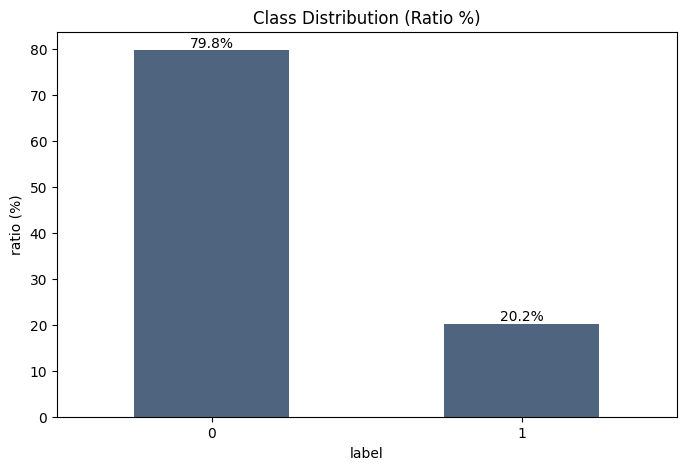

In [ ]:
plt.figure(figsize=(8,5))
(class_ratio.sort_values(ascending=False)).plot(kind="bar",color='#4e647f')
plt.title("Class Distribution (Ratio %)")
plt.xlabel(target_col)
plt.ylabel("ratio (%)")
plt.xticks(rotation=0)

for i, v in enumerate(class_ratio.sort_values(ascending=False)):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.show()


/tmp/ipykernel_1359/2932346048.py:32: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/2932346048.py:32: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/2932346048.py:32: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1359/2932346048.py:32: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


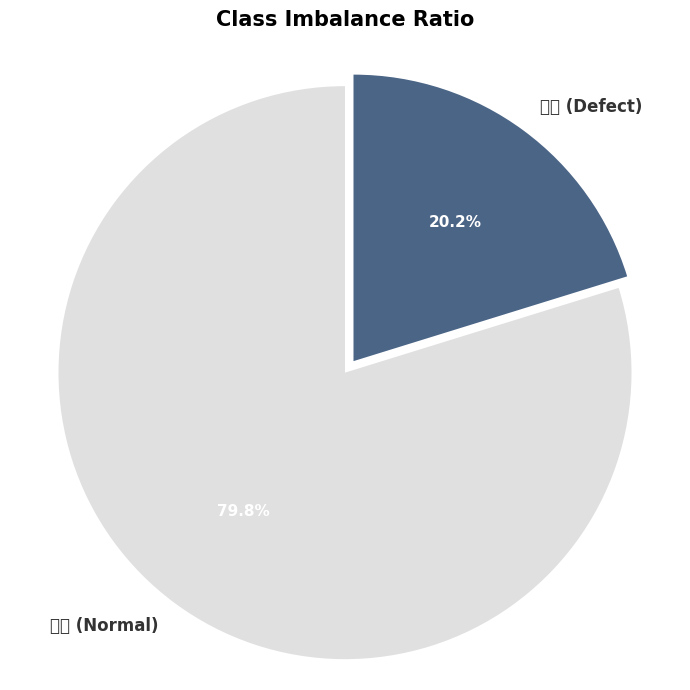

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 데이터 설정 (정상/불량 순서 유지)
labels = ['정상 (Normal)', '불량 (Defect)']
sizes = [imbalance_df.loc[0, 'count'], imbalance_df.loc[1, 'count']]
colors = ['#e0e0e0', '#4b6587']  # 정상: 연회색, 불량: 포인트 컬러

# 2. 시각화 설정
plt.figure(figsize=(7, 7))

# 파이 차트 생성
# explode: 불량 조각만 살짝 떼어내어 강조 (0.05 정도가 적당히 세련되어 보입니다)
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=(0, 0.05),
    shadow=False
)

# 텍스트 스타일링 (PPT 가독성용)
plt.setp(texts, size=12, fontweight='bold', color='#333333')
plt.setp(autotexts, size=11, fontweight='bold', color='white')

# 제목 및 레이아웃
plt.title("Class Imbalance Ratio", fontsize=15, pad=20, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.show()

# 이상치(Z-score)

In [ ]:
threshold = 3

for col in cols[:40]:

    mean = df[col].mean()
    std = df[col].std(ddof=1)

    z_score = (df[col] - mean) / std

    outliers = df[np.abs(z_score) > threshold]

    print(f"\n컬럼: {col}")
    print("이상치 개수:", len(outliers))
    print(outliers)


컬럼: stage1_temp
이상치 개수: 0
Empty DataFrame
Columns: [stage1_temp, stage2_temp, stage3_temp, stage4_temp, stage5_temp, stage1_humidity, stage2_humidity, stage3_humidity, stage4_humidity, stage5_humidity, stage1_flow_deviation, stage1_density_deviation, stage1_viscosity_deviation, stage1_co2_deviation, stage1_o2_deviation, stage1_n_deviation, stage2_flow_deviation, stage2_density_deviation, stage2_viscosity_deviation, stage2_co2_deviation, stage2_o2_deviation, stage2_n_deviation, stage3_flow_deviation, stage3_density_deviation, stage3_viscosity_deviation, stage3_co2_deviation, stage3_o2_deviation, stage3_n_deviation, stage4_flow_deviation, stage4_density_deviation, stage4_viscosity_deviation, stage4_co2_deviation, stage4_o2_deviation, stage4_n_deviation, stage5_flow_deviation, stage5_density_deviation, stage5_viscosity_deviation, stage5_co2_deviation, stage5_o2_deviation, stage5_n_deviation, label, z_score]
Index: []

[0 rows x 42 columns]

컬럼: stage2_temp
이상치 개수: 0
Empty DataFrame
Colum

In [ ]:
import numpy as np

threshold = 3

outlier_mask_total = pd.Series(False, index=df.index)

for col in cols[:40]:

    # 숫자형만 처리
    if not pd.api.types.is_numeric_dtype(df[col]):
        continue

    std = df[col].std(ddof=1)

    # 표준편차 0이면 스킵
    if std == 0 or np.isclose(std, 0):
        continue

    z_score = (df[col] - df[col].mean()) / std

    outlier_mask_col = np.abs(z_score) > threshold

    # 하나라도 이상치면 True
    outlier_mask_total |= outlier_mask_col.fillna(False)

# 🔥 이상치 행만 모은 데이터셋
df_outliers = df[outlier_mask_total].copy()

print("이상치 행 개수:", len(df_outliers))
df_outliers
df_outliers[df_outliers['label']==0]
df_outliers[df_outliers['label']==1]

이상치 행 개수: 1387


,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label,z_score
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-0.917519,2.905965,-0.914915,14.642069,-1.124235,2.249968,0.823538,1.574354,1,0.643990
52,30.28,31.15,28.23,29.66,29.46,74.22,78.55,72.88,76.43,76.80,...,-0.170443,-1.581241,-0.170443,-0.508294,-2.690047,2.653378,2.561481,0.207190,1,0.096184
107,30.52,31.63,30.93,31.08,29.98,76.05,75.81,75.84,77.96,68.20,...,1.260185,-1.896000,1.259928,0.825179,-3.395407,3.617051,-0.874367,2.911198,1,1.179647
166,29.72,29.33,30.25,28.12,30.62,73.26,72.21,71.32,76.66,74.06,...,4.915568,0.540630,4.915568,-2.383302,3.080413,-3.261180,-0.783490,-2.714545,1,-1.074519
214,31.63,31.16,29.42,30.85,31.44,78.14,77.26,75.52,76.14,78.51,...,-4.569577,-0.486929,-4.570152,-19.995969,-2.671882,-3.407665,1.208487,-4.100192,1,-1.629731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16917,28.20,31.46,28.58,30.70,30.20,67.50,69.60,70.65,68.56,69.55,...,-8.055844,0.292737,-8.055844,-16.304942,0.908860,2.108006,5.202535,-3.468671,1,-1.376688
16924,28.01,28.39,30.07,31.83,31.79,68.13,69.20,77.38,67.39,70.32,...,3.091978,-0.031065,3.091978,1.611913,-5.802702,-3.986148,1.293395,-1.690729,1,-0.664289
16925,31.51,30.88,28.43,29.21,29.28,67.88,69.58,71.64,68.53,74.56,...,-1.537584,1.113332,-1.537584,1.671842,-0.884694,-2.816455,3.538549,0.290902,1,0.129727
16971,29.79,28.69,31.46,30.67,31.23,78.84,77.78,72.69,77.66,77.89,...,5.271597,0.201292,5.271597,-0.533893,6.179496,1.734587,-2.584850,-4.117483,1,-1.636659


## 이상치 데이터 불균형

In [ ]:

target_col = "label"  # TODO: 타깃 컬럼명으로 변경

# 1. 클래스 카운트
class_counts = df_outliers[target_col].value_counts(dropna=False)
class_ratio = df_outliers[target_col].value_counts(normalize=True, dropna=False) * 100

imbalance_df = pd.DataFrame({
    "count": class_counts,
    "ratio_%": class_ratio.round(2)
}).sort_index()

display(imbalance_df)

# 2. imbalance 간단 지표(최대/최소 비율, IR)
# - 이진/다중분류 모두 동작
max_ratio = class_ratio.max()
min_ratio = class_ratio.min()
ir = class_counts.max() / class_counts.min()  # Imbalance Ratio (max/min)

print(f"[Class Ratio] max={max_ratio:.2f}%, min={min_ratio:.2f}%")
print(f"[Imbalance Ratio(IR=max/min)] {ir:.2f}")

,count,ratio_%
label,,
0,1030,74.26
1,357,25.74


[Class Ratio] max=74.26%, min=25.74%
[Imbalance Ratio(IR=max/min)] 2.89


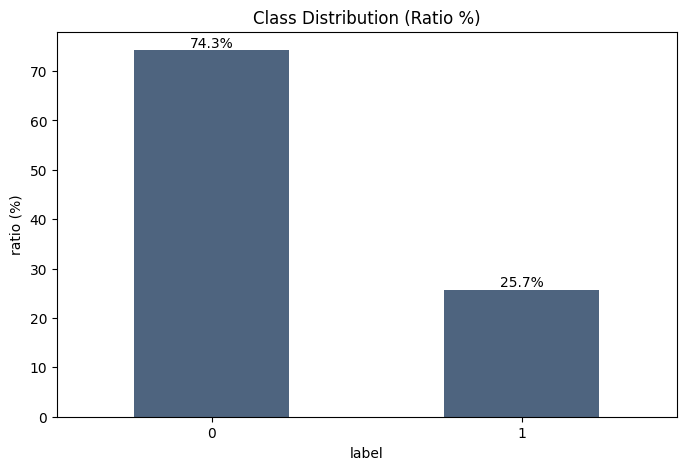

In [ ]:
plt.figure(figsize=(8,5))
(class_ratio.sort_values(ascending=False)).plot(kind="bar",color='#4e647f')
plt.title("Class Distribution (Ratio %)")
plt.xlabel(target_col)
plt.ylabel("ratio (%)")
plt.xticks(rotation=0)

for i, v in enumerate(class_ratio.sort_values(ascending=False)):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.show()

# 로지스틱 회귀(컬럼)

In [ ]:
df_normal

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,14.243738,-4.937284,0.089265,-4.937284,12.361204,3.886517,3.381750,5.827666,-0.056206,1
1,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,5.685728,-0.955917,0.871249,-0.955908,1.587669,1.665659,-0.052572,-0.597566,-2.745544,0
2,29.96,29.22,28.39,31.96,31.12,68.60,67.80,70.09,71.88,76.71,...,5.497906,-2.134062,-1.188985,-2.134062,4.550075,0.020477,3.230979,-0.032255,0.157905,0
3,28.42,28.22,31.63,28.54,31.17,77.29,72.56,76.22,75.59,71.37,...,-10.989594,1.181395,-0.594650,1.181395,-3.064628,0.330088,-2.881577,-1.369120,-0.853303,1
4,31.16,29.84,30.00,29.24,28.42,75.63,73.83,74.09,70.16,74.79,...,13.596677,-4.309286,-0.118556,-4.309190,-4.286445,4.669955,-0.126073,1.521476,-4.221516,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15606,29.68,29.91,30.18,30.78,28.06,77.29,75.94,75.59,73.05,73.09,...,-6.240376,-1.627189,-0.384339,-1.627189,-1.251171,-0.972060,2.343462,-0.342200,1.252295,0
15607,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,-1.139003,2.228396,0.044608,2.228396,5.861357,0.414884,-1.108650,-0.813562,1.744824,1
15608,28.44,28.81,31.56,30.57,28.79,72.11,70.08,73.60,73.15,68.72,...,3.729189,-0.858941,0.124091,-0.859033,-0.722216,4.351513,0.000299,1.684467,-1.652202,0
15609,28.17,28.47,28.79,28.99,29.71,75.93,77.20,67.56,76.45,76.70,...,-1.567624,-2.373612,-0.820434,-2.373612,-5.930715,1.433596,-2.000998,4.125043,-0.552398,0


c:\python\Python39\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 70.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\python\Python39\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BY

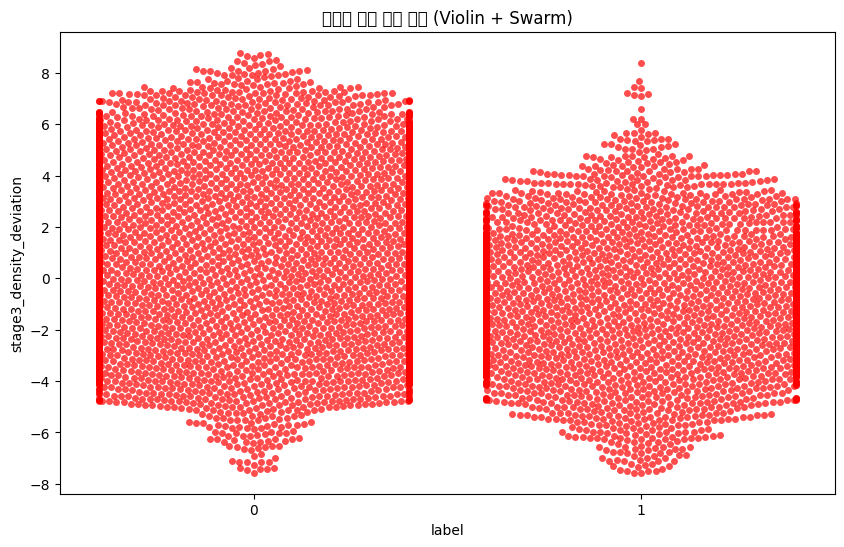

In [ ]:
plt.figure(figsize=(10, 6))

# 2. 그 위에 스웜 플롯으로 실제 데이터를 찍음
sns.swarmplot(data=df_normal, x='label', y='stage3_density_deviation' ,color='red', alpha=0.7)

plt.title("요일별 결제 금액 분포 (Violin + Swarm)")
plt.show()

# pca

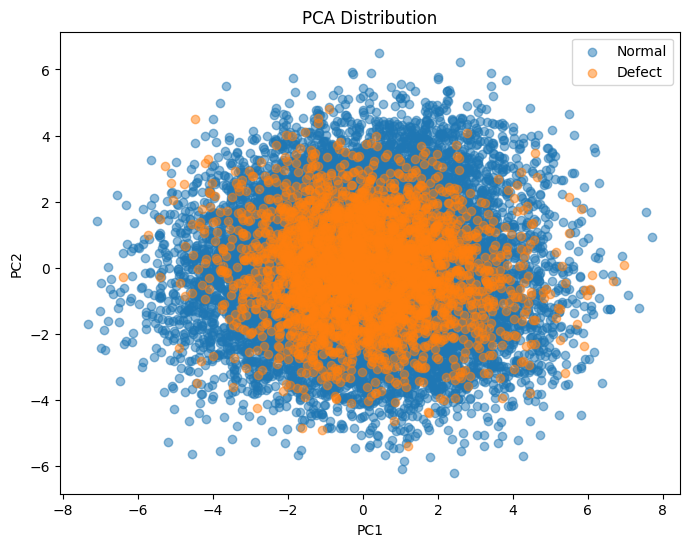

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# X, y 준비
X = df_normal.drop('label', axis=1)
y = df_normal['label']

# 1. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA 2차원
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. 시각화
plt.figure(figsize=(8,6))

plt.scatter(X_pca[y==0, 0], X_pca[y==0, 1], alpha=0.5, label='Normal')
plt.scatter(X_pca[y==1, 0], X_pca[y==1, 1], alpha=0.5, label='Defect')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Distribution')
plt.legend()
plt.show()

In [ ]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.11290864 0.09006153]
Total explained variance: 0.2029701743213044


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# X, y 분리
X = df_normal.drop('label', axis=1)
y = df_normal['label']

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 3차원
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 데이터프레임 생성
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['label'] = y.values

fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='label',
    opacity=0.6
)

fig.update_layout(title='3D PCA Distribution')
fig.show()

# 파생변수

## stage(s)-stage(s-1)

In [ ]:
df_new=df.copy()



In [ ]:
import re

# 1. 패턴 수정:
# ^stage([1-5])_  -> 시작이 stage + 1~5사이 숫자 + 언더바
# (.*)$           -> 그 뒤에 오는 모든 문자열을 하나의 그룹으로 캡처
pattern = re.compile(r"^stage([1-5])_(.*)$")

base_features = set()

# 컬럼명 리스트(cols)에서 공통 피처 이름 추출
for col in df.columns[10:]:
    m = pattern.match(col)
    if m:
        # group(2)는 'temp' 또는 'co2_deviation' 전체를 가져옵니다.
        base_features.add(m.group(2))

base_features = list(base_features)

# 2. 차분 변수 생성
for feat in base_features:
    # 1단계부터 4단계까지 돌면서 (s+1) - (s) 계산
    for s in range(1, 5):
        curr_col = f"stage{s}_{feat}"
        next_col = f"stage{s+1}_{feat}"

        # 원본 데이터에 두 컬럼이 모두 존재하는 경우에만 계산
        if curr_col in df.columns and next_col in df.columns:
            new_col_name = f"{feat}_diff_{s+1}_{s}"
            df_new[new_col_name] = df[next_col] - df[curr_col]

print(f"추출된 피처 목록: {base_features}")
print(f"차분 변수 생성 완료 (피처당 최대 4개씩 생성)")
df_new
new_cols = df_new.columns

추출된 피처 목록: ['density_deviation', 'o2_deviation', 'viscosity_deviation', 'flow_deviation', 'n_deviation', 'co2_deviation']
차분 변수 생성 완료 (피처당 최대 4개씩 생성)


C:\Users\jsuai\AppData\Local\Temp\ipykernel_7800\2616970756.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df_new.groupby("bin")["label"].count()
C:\Users\jsuai\AppData\Local\Temp\ipykernel_7800\2616970756.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect = df_new.groupby("bin")["label"].sum()


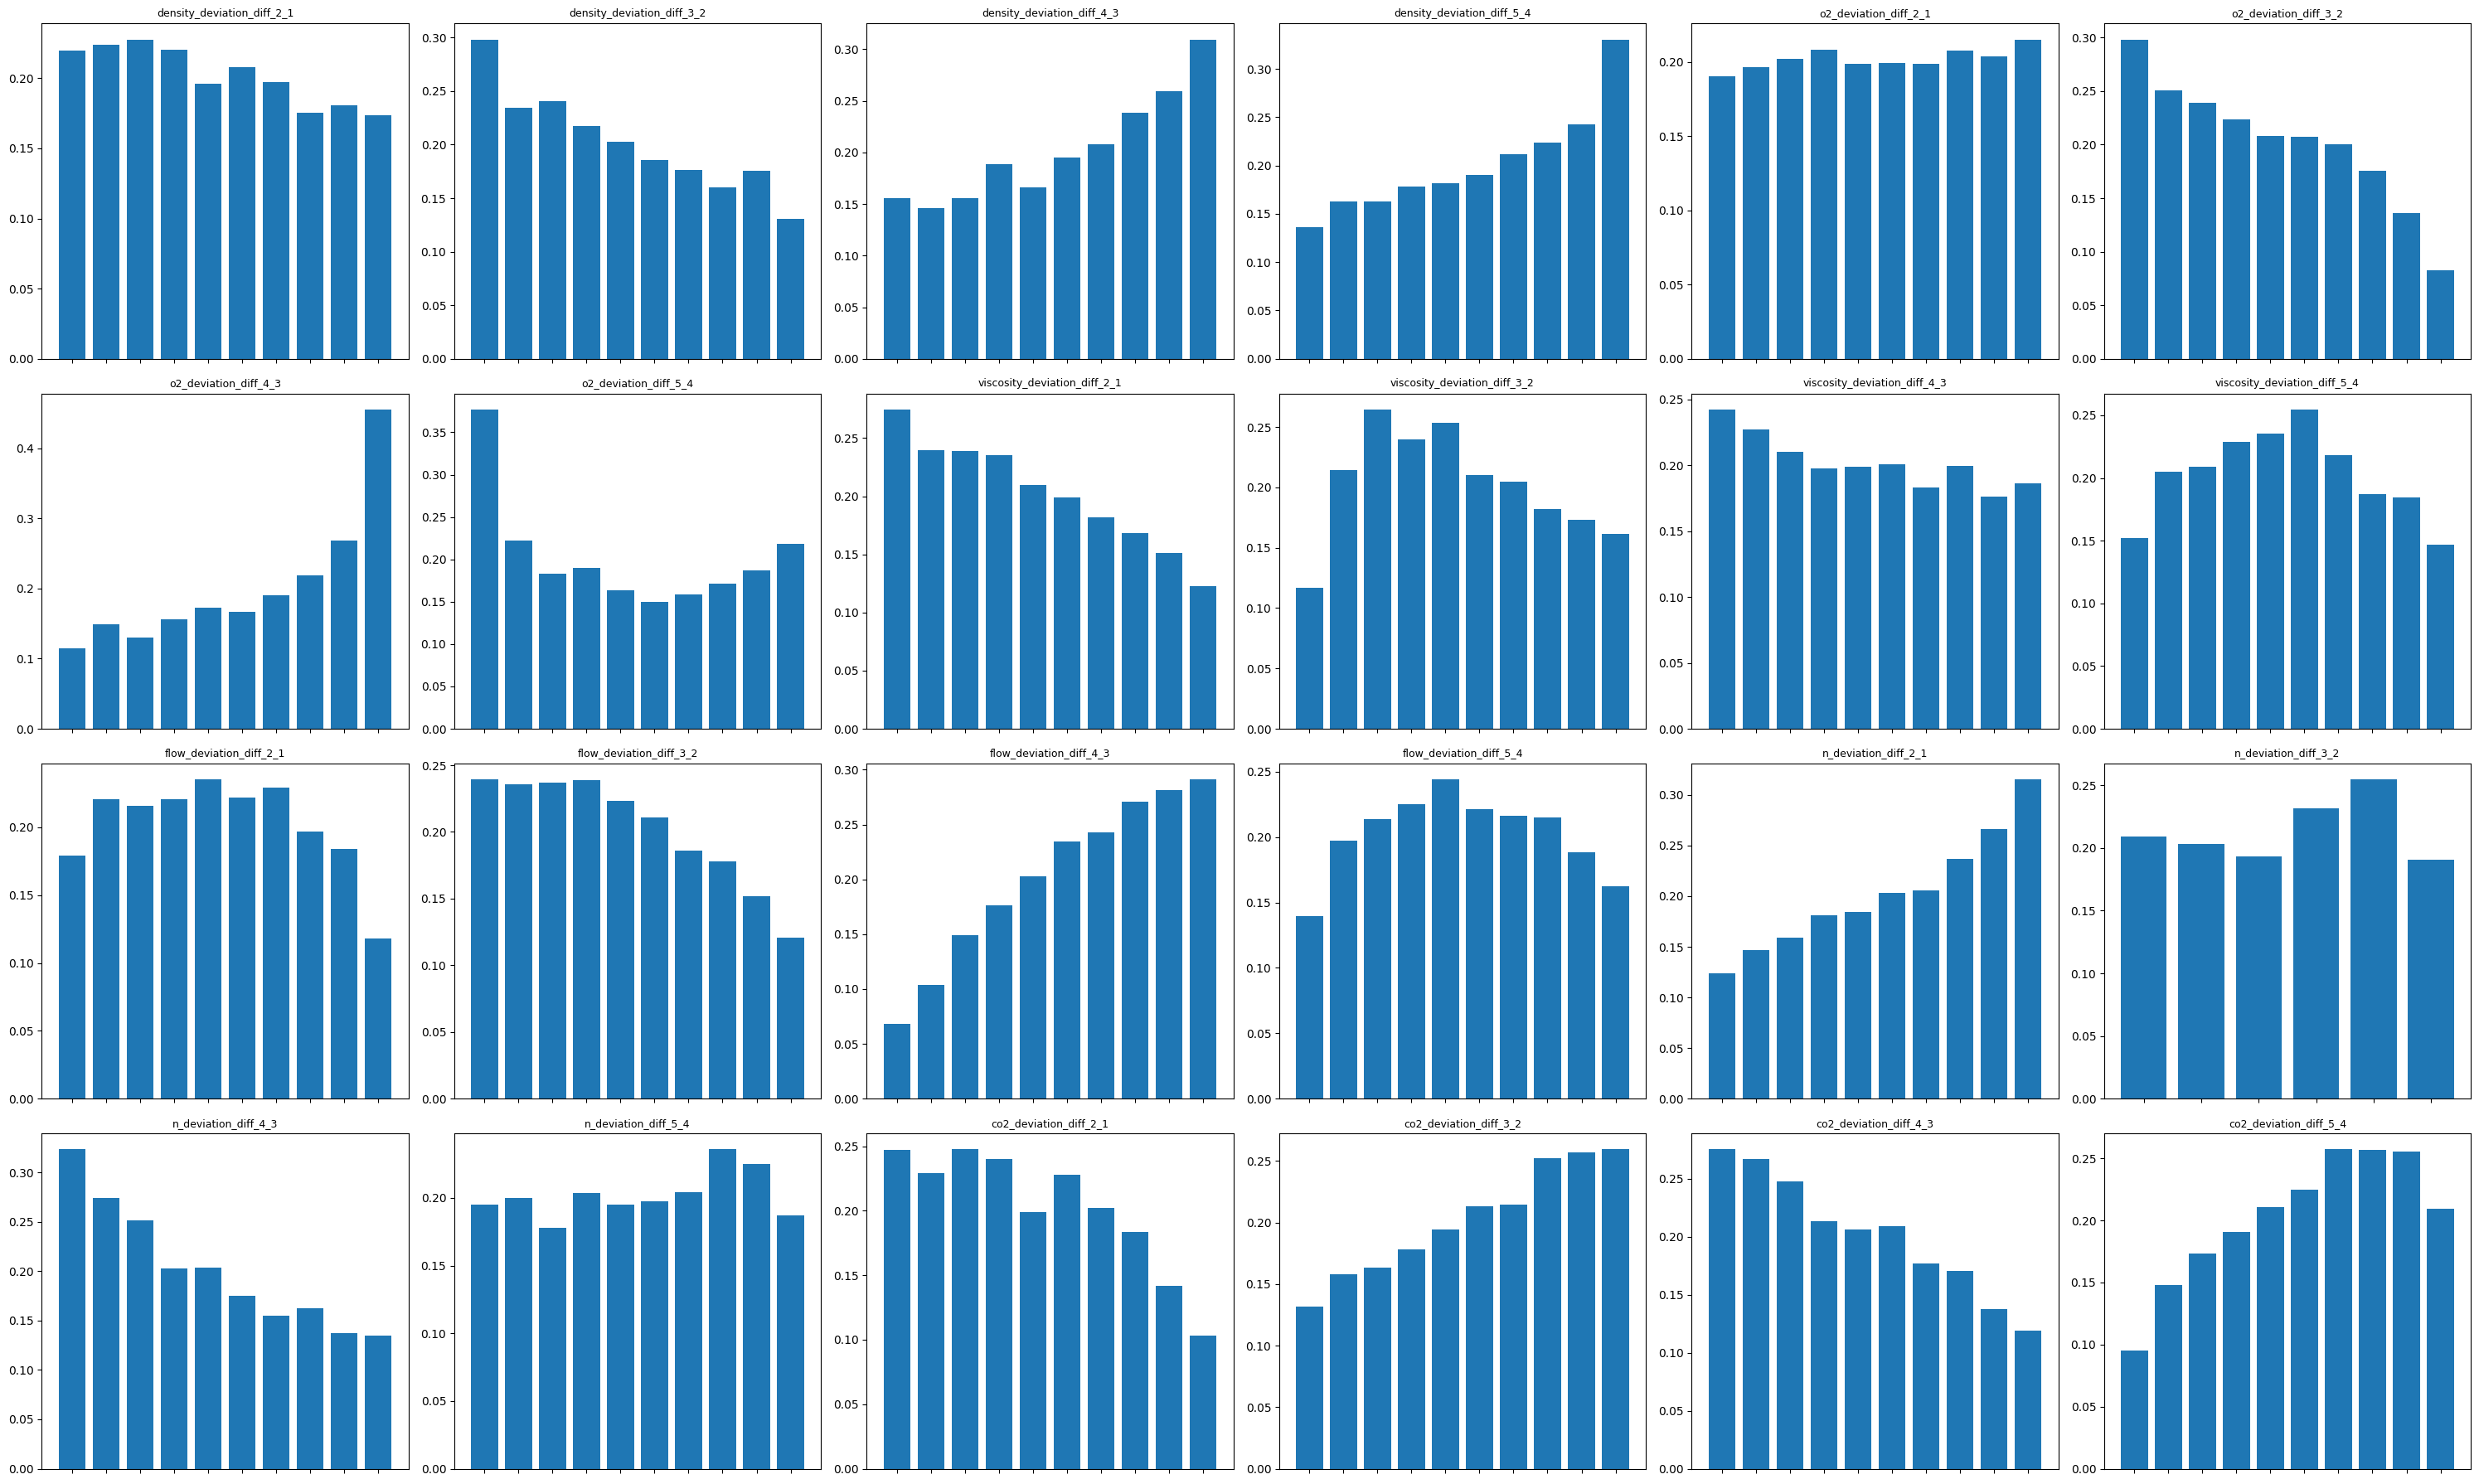

In [ ]:
numeric_cols = new_cols[41:]

cols_per_page = 24  # 5x6 = 30

for start in range(0, len(numeric_cols), cols_per_page):
    subset = numeric_cols[start:start+cols_per_page]

    fig, axes = plt.subplots(4, 6, figsize=(30, 18))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        # 10구간 분할
        df_new["bin"] = pd.qcut(df_new[col], q=10, duplicates='drop')

        total = df_new.groupby("bin")["label"].count()
        defect = df_new.groupby("bin")["label"].sum()
        defect_ratio = defect / total

        axes[i].bar(range(len(defect_ratio)), defect_ratio)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks(range(len(defect_ratio)))
        axes[i].set_xticklabels([], rotation=45)

    # 남는 subplot 제거
    for j in range(len(subset), 24):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
df_new2=df_new.copy()

# 1. 시각화 결과, 경향성이 뚜렷하여 '살릴' 변수 리스트
best_diff_features = [
    "viscosity_deviation_diff_2_1", "viscosity_deviation_diff_4_3",
    "flow_deviation_diff_2_1", "flow_deviation_diff_3_2", "flow_deviation_diff_4_3",
    "density_deviation_diff_3_2", "density_deviation_diff_4_3", "density_deviation_diff_5_4",
    "n_deviation_diff_2_1", "n_deviation_diff_4_3",
    "co2_deviation_diff_3_2", "co2_deviation_diff_4_3", "co2_deviation_diff_5_4",
    "o2_deviation_diff_3_2", "o2_deviation_diff_4_3"
]

# 2. 전체 생성했던 차분 변수 리스트 (기존에 생성한 컬럼들)
all_diff_cols = [c for c in df_new.columns if "_diff_" in c]

# 3. '살릴 변수'에 포함되지 않는 나머지 차분 변수들을 식별하여 삭제
cols_to_drop = [c for c in all_diff_cols if c not in best_diff_features]

# 데이터프레임에서 제거
df_new2.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"✅ 삭제된 변수 개수: {len(cols_to_drop)}개")
print(f"🚀 남은 핵심 변수 개수: {len(best_diff_features)}개")
print(f"남은 컬럼 예시: {df_new.columns[-5:].tolist()}")

✅ 삭제된 변수 개수: 9개
🚀 남은 핵심 변수 개수: 15개
남은 컬럼 예시: ['o2_deviation_diff_2_1', 'o2_deviation_diff_3_2', 'o2_deviation_diff_4_3', 'o2_deviation_diff_5_4', 'bin']


In [ ]:
df_new2

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,density_deviation_diff_4_3,density_deviation_diff_5_4,n_deviation_diff_2_1,n_deviation_diff_4_3,co2_deviation_diff_3_2,co2_deviation_diff_4_3,co2_deviation_diff_5_4,o2_deviation_diff_3_2,o2_deviation_diff_4_3,bin
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-1.511622,18.037460,2.614196,0.520914,-1.529646,-0.144646,2.631949,0.925383,-2.659399,"(0.842, 1.78]"
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,-2.045809,14.587919,-1.901855,2.669330,-2.305969,15.284308,-10.861989,4.413611,-8.911360,"(5.79, 15.748]"
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,-0.280881,4.304581,-0.744636,2.265021,-4.661767,11.090270,-5.738300,-2.194864,-0.064352,"(-0.105, 0.842]"
3,29.96,29.22,28.39,31.96,31.12,68.60,67.80,70.09,71.88,76.71,...,-0.937383,5.676278,-2.297899,1.918695,3.413433,2.086969,-2.266927,2.437861,-5.682925,"(1.78, 2.821]"
4,30.09,29.58,28.06,30.46,28.84,78.24,67.31,72.63,77.78,74.76,...,6.769008,11.174668,1.947213,-2.866522,-2.047230,8.451853,-7.776126,-0.390052,-0.552309,"(1.78, 2.821]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16993,29.68,29.91,30.18,30.78,28.06,77.29,75.94,75.59,73.05,73.09,...,-2.675502,0.609928,-5.504090,4.566098,0.059291,-9.897936,8.583838,-2.325469,0.057315,"(0.842, 1.78]"
16994,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,1.379981,6.538403,2.628613,-1.927855,-0.333888,0.367537,0.030352,-2.802697,5.036264,"(-4.106, -2.354]"
16995,28.44,28.81,31.56,30.57,28.79,72.11,70.08,73.60,73.15,68.72,...,0.311072,-2.600836,-4.164280,4.286991,2.584160,2.269753,-3.728889,0.659924,-1.884552,"(1.78, 2.821]"
16996,28.17,28.47,28.79,28.99,29.71,75.93,77.20,67.56,76.45,76.70,...,-1.678086,-5.770398,1.460589,-1.643427,1.581813,-4.276463,-0.433374,-1.761816,-1.077365,"(5.79, 15.748]"


## stage5-1

In [ ]:
df_new51=df.copy()



In [ ]:
import re

# 1. 분석 대상 컬럼 설정 (앞 10개 제외)
target_cols = df_new51.columns[10:]

# 2. 선정된 알짜 피처 5개 (이름만 지정)
target_base_features = [
    "flow_deviation",
    "density_deviation",
    "viscosity_deviation",
    "n_deviation",
    "co2_deviation",
    "o2_deviation"
]

# 3. 파생변수 생성 (std, slope, diff_5_1)
x = np.array([1, 2, 3, 4, 5])

for feat in target_base_features:
    # 컬럼명 리스트 생성 (예: stage1_flow_deviation)
    # 반드시 target_cols 안에 있는 컬럼인지 확인하며 진행
    stage_cols = [f"stage{s}_{feat}" for s in [1, 2, 3, 4, 5]]

    # 5개 스테이지 컬럼이 모두 target_cols(10번 이후)에 존재하는지 체크
    if all(col in target_cols for col in stage_cols):
        # (1) 변동성: std
        df_new51[f"{feat}_std"] = df_new51[stage_cols].std(axis=1)

        # (2) 추세: slope (기울기)
        # 5개 지점을 잇는 선형 추세
        df_new51[f"{feat}_slope"] = df_new51[stage_cols].apply(
            lambda y: np.polyfit(x, y.values, 1)[0], axis=1
        )

        # (3) 전체 변화량: stage5 - stage1
        df_new51[f"{feat}_diff_5_1"] = df_new51[f"stage5_{feat}"] - df_new51[f"stage1_{feat}"]

# 4. 정리: 새로 만든 파생변수 리스트 확인
generated_cols = [c for c in df_new51.columns if any(suffix in c for suffix in ["_std", "_slope", "_diff_5_1"])]

print(f"✅ 파생변수 생성 완료 (총 {len(generated_cols)}개)")
print(f"📊 생성된 컬럼 예시: {generated_cols[:5]}")
new51_cols=df_new51.columns

✅ 파생변수 생성 완료 (총 18개)
📊 생성된 컬럼 예시: ['flow_deviation_std', 'flow_deviation_slope', 'flow_deviation_diff_5_1', 'density_deviation_std', 'density_deviation_slope']


C:\Users\jsuai\AppData\Local\Temp\ipykernel_9016\3218931170.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df_new51.groupby("bin")["label"].count()
C:\Users\jsuai\AppData\Local\Temp\ipykernel_9016\3218931170.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect = df_new51.groupby("bin")["label"].sum()


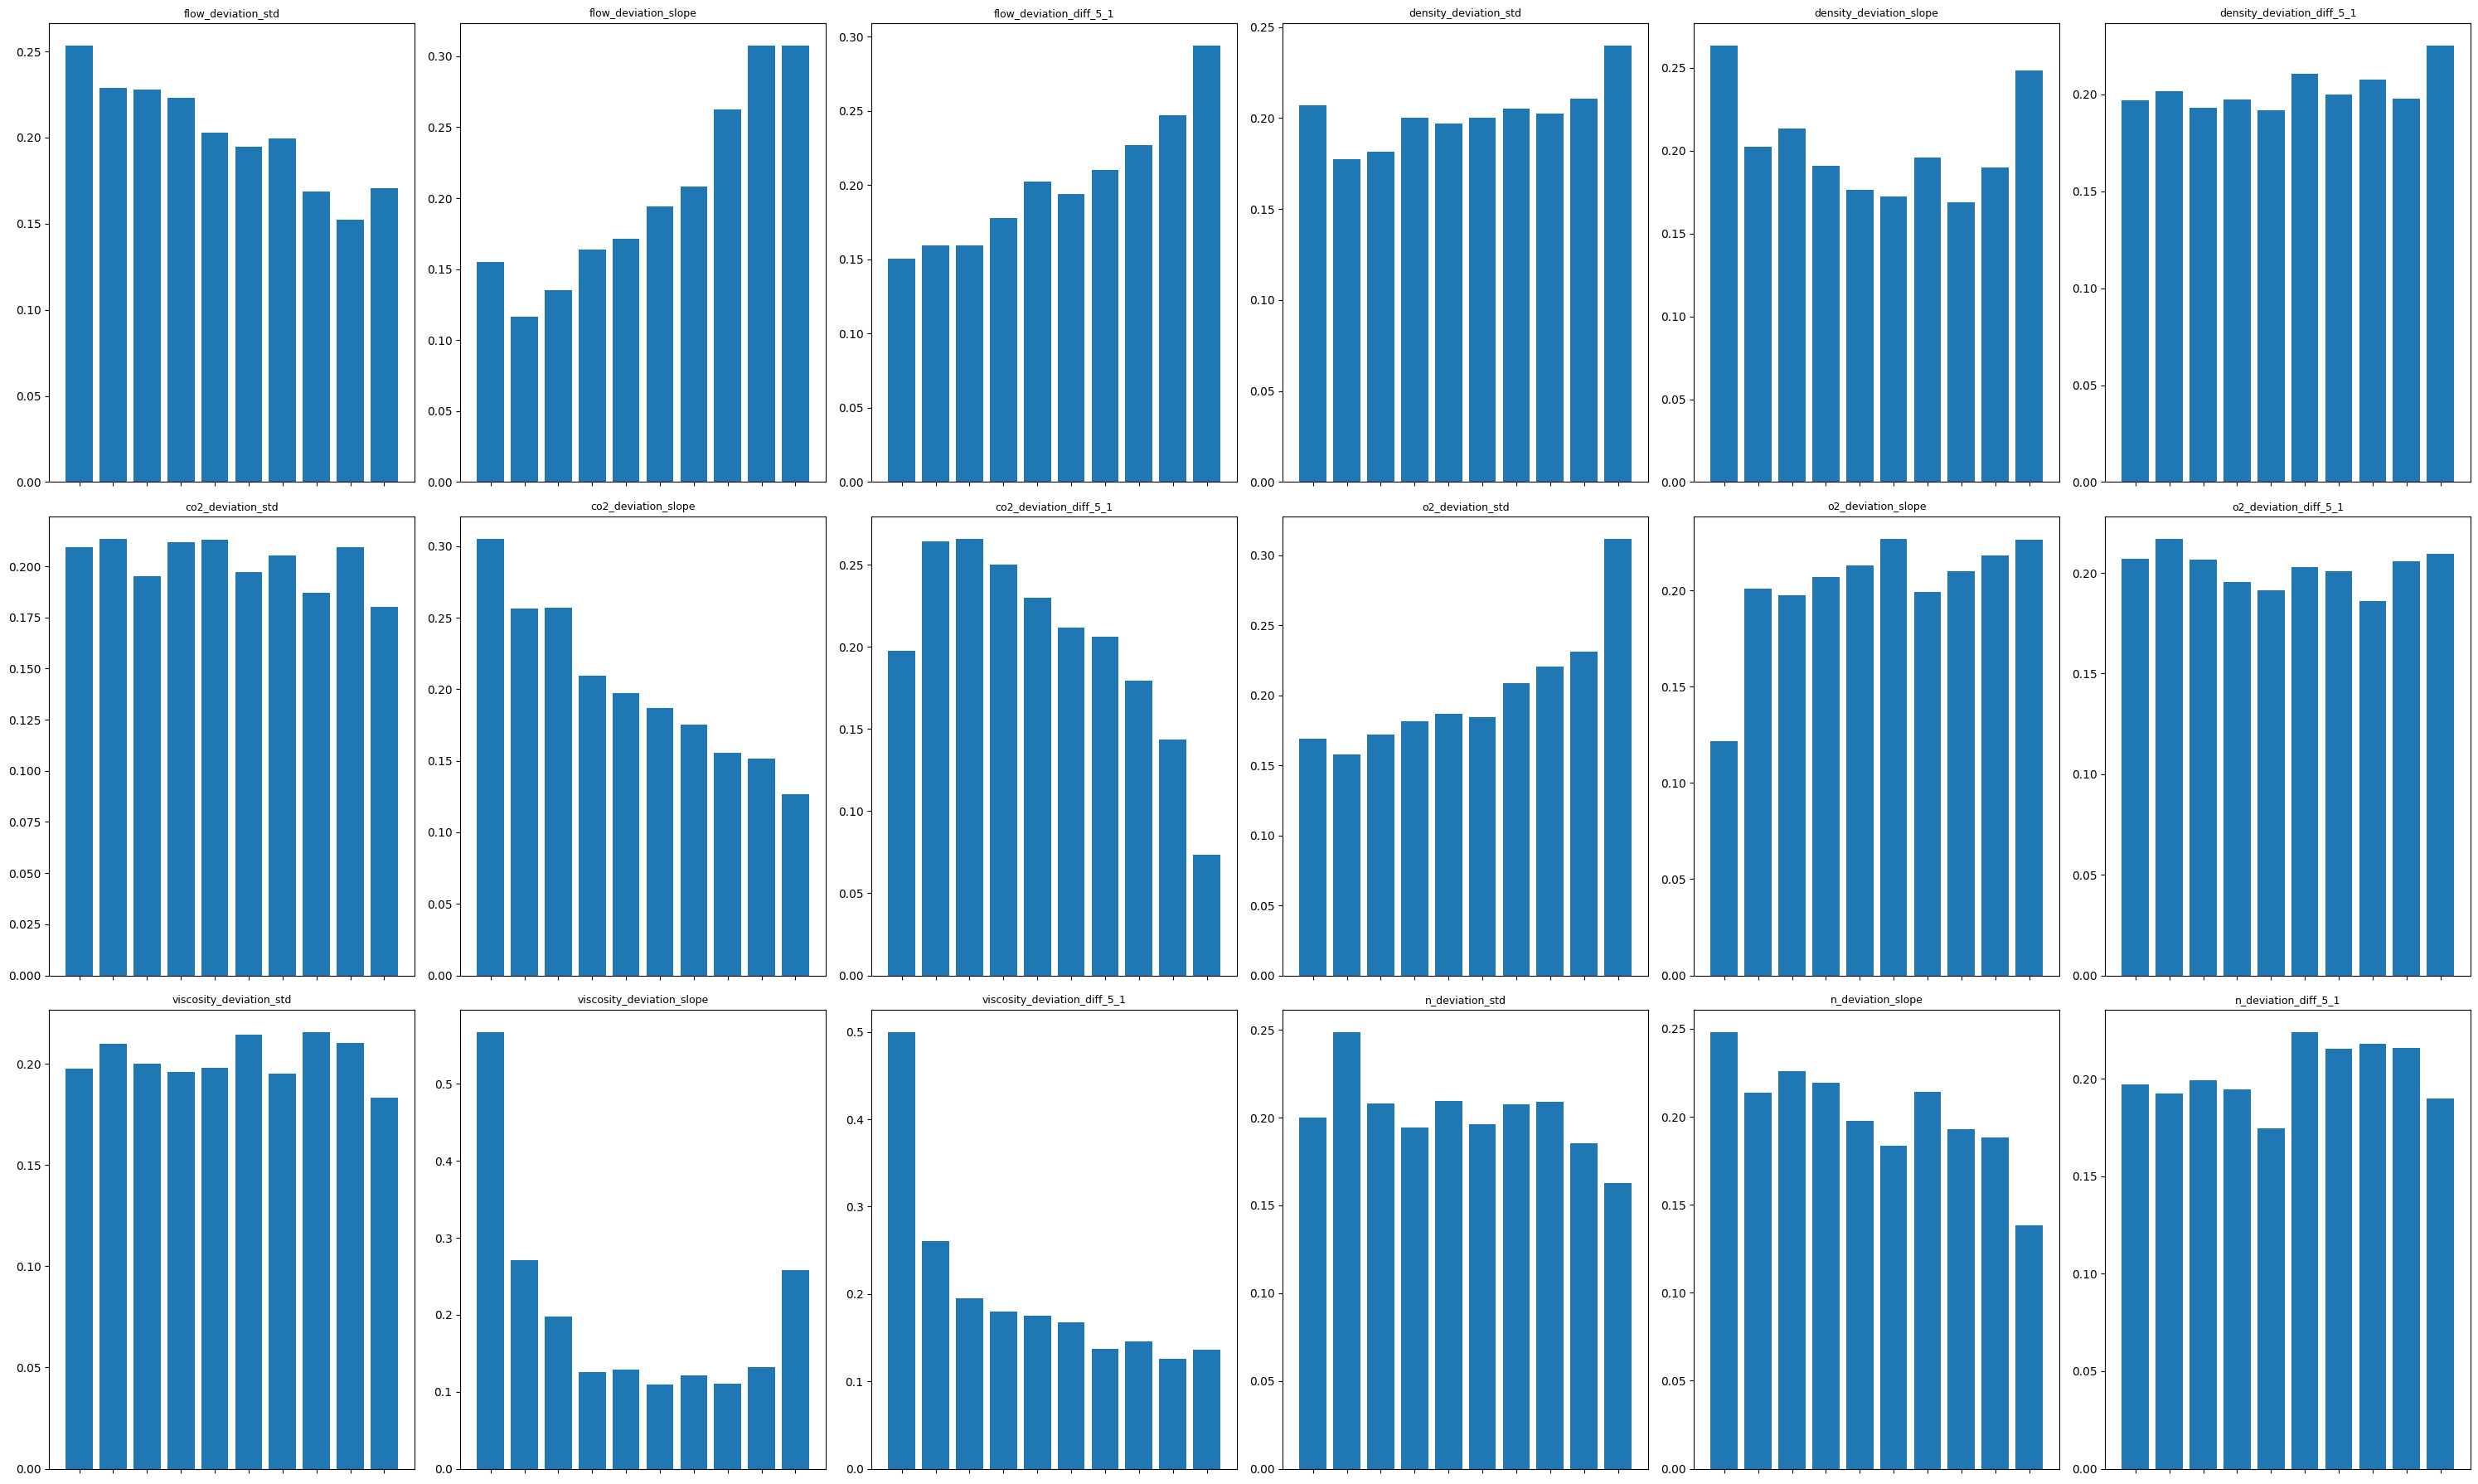

In [ ]:
numeric_cols = new51_cols[41:]

cols_per_page = 18  # 5x6 = 30

for start in range(0, len(numeric_cols), cols_per_page):
    subset = numeric_cols[start:start+cols_per_page]

    fig, axes = plt.subplots(3, 6, figsize=(30, 18))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        # 10구간 분할
        df_new51["bin"] = pd.qcut(df_new51[col], q=10, duplicates='drop')

        total = df_new51.groupby("bin")["label"].count()
        defect = df_new51.groupby("bin")["label"].sum()
        defect_ratio = defect / total

        axes[i].bar(range(len(defect_ratio)), defect_ratio)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks(range(len(defect_ratio)))
        axes[i].set_xticklabels([], rotation=45)

    # 남는 subplot 제거
    for j in range(len(subset), 18):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jsuai\AppData\Roaming\Python\Python39\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) m

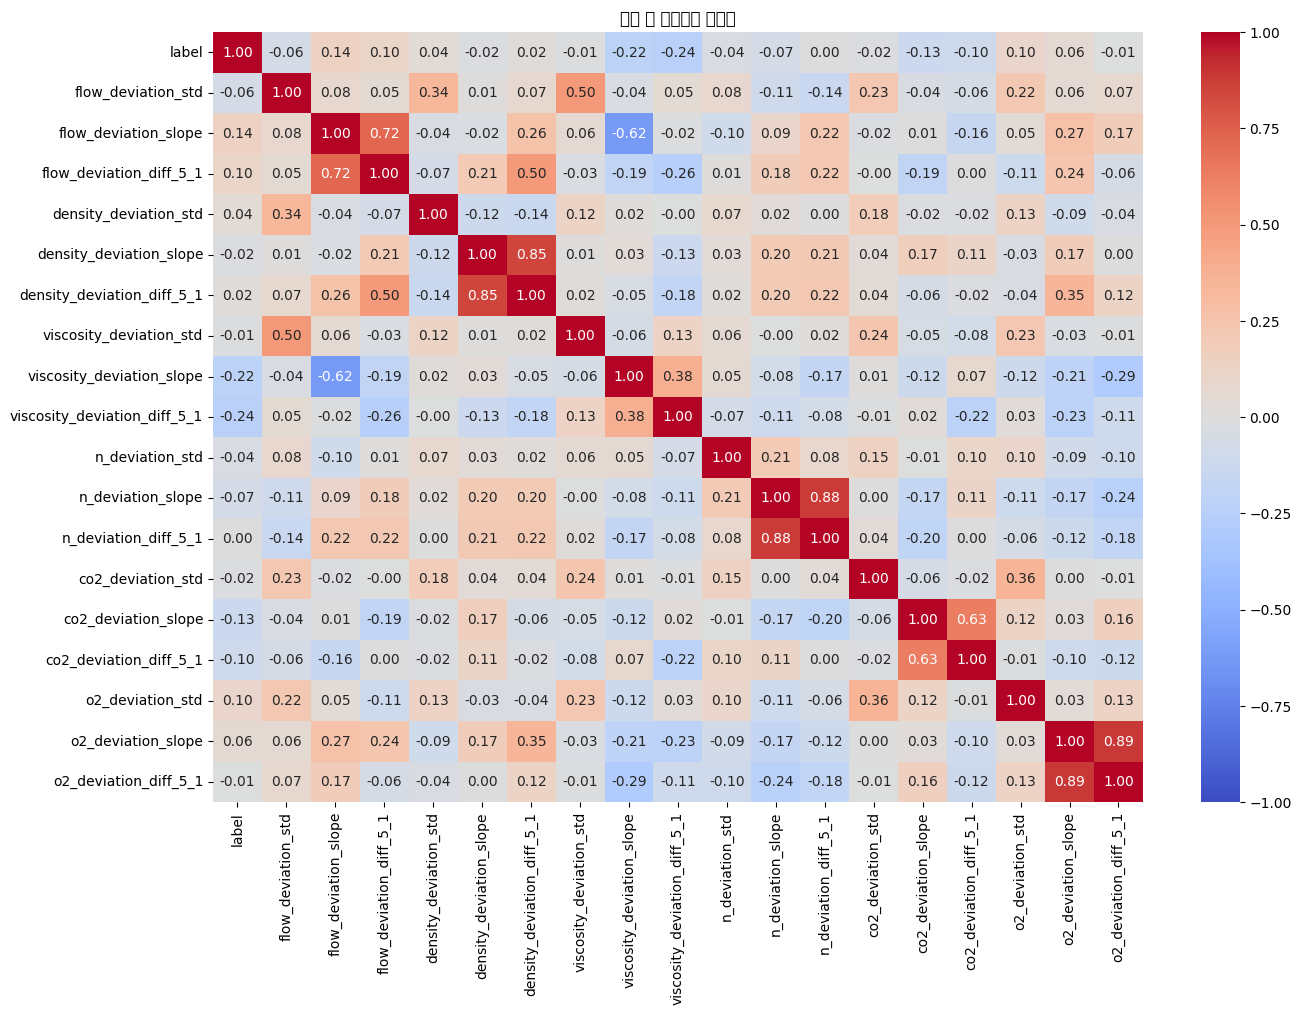

In [ ]:
# 상관계수 계산 (숫자형 데이터만)
corr = df_new51[new51_cols[40:]].corr(numeric_only=True)

plt.figure(figsize=(15, 10))
#fmt='.nf' : 소수점 n자리까지
#cmap='coolwarm_r' -> '_r' : 색깔 진하기 큰수/작은수 방향 결정
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

plt.title("변수 간 상관관계 히트맵")
plt.show()

In [ ]:
df_all=pd.concat([df_new, df_new51[new51_cols[41:]]], axis=1)

df_all

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,viscosity_deviation_diff_5_1,n_deviation_std,n_deviation_slope,n_deviation_diff_5_1,co2_deviation_std,co2_deviation_slope,co2_deviation_diff_5_1,o2_deviation_std,o2_deviation_slope,o2_deviation_diff_5_1
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-6.840357,1.232475,0.412791,1.803498,1.458915,-0.294571,-0.635711,1.457045,0.357441,2.654213
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,3.047645,1.327056,0.391334,0.622005,5.861192,1.140155,-0.788395,4.186814,0.679944,5.648596
2,31.25,29.16,31.45,30.74,30.26,67.98,78.42,70.97,67.71,70.73,...,-0.021256,1.319315,-0.192779,-2.096408,4.029532,0.275713,-1.835686,1.091214,-0.545695,-1.598866
3,29.96,29.22,28.39,31.96,31.12,68.60,67.80,70.09,71.88,76.71,...,-1.339115,1.451652,0.385407,0.967686,2.002737,0.420285,-0.648777,2.051894,-0.479623,-0.775581
4,30.09,29.58,28.06,30.46,28.84,78.24,67.31,72.63,77.78,74.76,...,0.526662,1.246556,-0.136666,0.749932,3.509104,0.685523,0.225306,0.927549,0.337184,2.157101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16993,29.68,29.91,30.18,30.78,28.06,77.29,75.94,75.59,73.05,73.09,...,-0.160953,3.027233,0.596338,0.698641,4.320606,-1.263278,-1.397069,0.968498,-0.124423,0.511961
16994,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,-0.456637,1.234961,0.287409,2.400974,1.321242,-0.558537,-2.809508,1.816258,0.037781,-0.927881
16995,28.44,28.81,31.56,30.57,28.79,72.11,70.08,73.60,73.15,68.72,...,4.966663,2.120741,0.097983,-1.653581,2.264726,0.888193,2.014009,1.134859,-0.180961,-0.292493
16996,28.17,28.47,28.79,28.99,29.71,75.93,77.20,67.56,76.45,76.70,...,3.979261,0.823538,-0.147303,0.085198,1.965819,-0.540515,-1.355248,2.468487,0.539003,4.114603


In [ ]:
X = df_all.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9607    0.9919    0.9761      2713
          불량     0.9633    0.8399    0.8974       687

    accuracy                         0.9612      3400
   macro avg     0.9620    0.9159    0.9367      3400
weighted avg     0.9612    0.9612    0.9602      3400

Confusion matrix:
 [[2691   22]
 [ 110  577]]


In [ ]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(
    iterations=1000,          # 충분히 학습하되 조기종료 활용
    scale_pos_weight=4.0,     # ★ 이거 하나는 꼭 넣어주세요!
    loss_function='Logloss',
    random_seed=42,
    task_type="CPU",
    verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))



===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9793    0.9779    0.9786      2713
          불량     0.9132    0.9185    0.9158       687

    accuracy                         0.9659      3400
   macro avg     0.9462    0.9482    0.9472      3400
weighted avg     0.9660    0.9659    0.9659      3400

Confusion matrix:
 [[2653   60]
 [  56  631]]


In [ ]:
from catboost import CatBoostClassifier, Pool
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 1. 가중치만 4.0으로 고정 (8:2 비율 대응)
# 다른 파라미터는 기본값으로 둡니다.
model = CatBoostClassifier(
    iterations=1000,          # 충분히 학습하되 조기종료 활용
    scale_pos_weight=4.0,     # ★ 이거 하나는 꼭 넣어주세요!
    loss_function='Logloss',
    random_seed=42,
    task_type="CPU",
    verbose=0
)

# 2. 전용 Pool 생성 (X_train, y_train 등이 준비되어 있어야 함)
train_pool = Pool(X_tr, y_tr)
val_pool = Pool(X_val, y_val)

# 3. 변수 선택 실행
summary = model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_tr.shape[1])),
    num_features_to_select=20,  # 50개 중 핵심 20개만 고르기
    steps=5,                    # 5단계로 나누어 제거 (속도 빠름)
    algorithm='RecursiveByShapValues',
    train_final_model=True
)

# 4. 선택된 컬럼들 저장
selected_indices = summary['selected_features']
selected_features = [X_tr.columns[i] for i in selected_indices]

print(f"선택된 변수({len(selected_features)}개):", selected_features)

Learning rate set to 0.05714
Step #1 out of 5

bestTest = 0.1733173018
bestIteration = 553

Shrink model to first 554 iterations.
Feature #71 eliminated
Feature #79 eliminated
Feature #76 eliminated
Feature #9 eliminated
Feature #3 eliminated
Feature #33 eliminated
Feature #15 eliminated
Feature #4 eliminated
Feature #77 eliminated
Feature #7 eliminated
Feature #2 eliminated
Feature #59 eliminated
Feature #57 eliminated
Feature #0 eliminated
Feature #8 eliminated
Feature #44 eliminated
Feature #6 eliminated
Feature #5 eliminated
Feature #70 eliminated
Feature #14 eliminated
Step #2 out of 5

bestTest = 0.1628588563
bestIteration = 457

Shrink model to first 458 iterations.
Feature #62 eliminated
Feature #60 eliminated
Feature #51 eliminated
Feature #1 eliminated
Feature #30 eliminated
Feature #20 eliminated
Feature #16 eliminated
Feature #63 eliminated
Feature #73 eliminated
Feature #67 eliminated
Feature #68 eliminated
Feature #80 eliminated
Feature #50 eliminated
Feature #17 eliminat

In [ ]:


X = df_all[[
    'stage1_flow_deviation', 'stage1_density_deviation', 'stage2_viscosity_deviation', 'stage2_co2_deviation',
    'stage2_n_deviation', 'stage3_flow_deviation', 'stage3_density_deviation', 'stage3_co2_deviation', 'stage4_flow_deviation',
    'stage4_density_deviation', 'stage4_o2_deviation', 'stage5_viscosity_deviation', 'stage5_co2_deviation', 'stage5_o2_deviation', 'stage5_n_deviation',
    'o2_deviation_diff_4_3', 'viscosity_deviation_diff_3_2', 'density_deviation_diff_5_1', 'viscosity_deviation_diff_5_1', 'co2_deviation_diff_5_1']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9670    0.9934    0.9800      2713
          불량     0.9706    0.8661    0.9154       687

    accuracy                         0.9676      3400
   macro avg     0.9688    0.9297    0.9477      3400
weighted avg     0.9677    0.9676    0.9669      3400

Confusion matrix:
 [[2695   18]
 [  92  595]]


In [ ]:
from catboost import CatBoostClassifier, Pool
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 1. 가중치만 4.0으로 고정 (8:2 비율 대응)
# 다른 파라미터는 기본값으로 둡니다.
model = CatBoostClassifier(
    iterations=1000,          # 충분히 학습하되 조기종료 활용
    scale_pos_weight=4.0,     # ★ 이거 하나는 꼭 넣어주세요!
    loss_function='Logloss',
    random_seed=42,
    task_type="CPU",
    verbose=0
)

# 2. 전용 Pool 생성 (X_train, y_train 등이 준비되어 있어야 함)
train_pool = Pool(X_tr, y_tr)
val_pool = Pool(X_val, y_val)

# 3. 변수 선택 실행
summary = model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_tr.shape[1])),
    num_features_to_select=30,  # 50개 중 핵심 20개만 고르기
    steps=5,                    # 5단계로 나누어 제거 (속도 빠름)
    algorithm='RecursiveByShapValues',
    train_final_model=True
)

# 4. 선택된 컬럼들 저장
selected_indices = summary['selected_features']
selected_features = [X_tr.columns[i] for i in selected_indices]

print(f"선택된 변수({len(selected_features)}개):", selected_features)

Learning rate set to 0.05714
Step #1 out of 5

bestTest = 0.1733173018
bestIteration = 553

Shrink model to first 554 iterations.
Feature #71 eliminated
Feature #79 eliminated
Feature #76 eliminated
Feature #9 eliminated
Feature #3 eliminated
Feature #33 eliminated
Feature #15 eliminated
Feature #4 eliminated
Feature #77 eliminated
Feature #7 eliminated
Feature #2 eliminated
Feature #59 eliminated
Feature #57 eliminated
Feature #0 eliminated
Feature #8 eliminated
Step #2 out of 5

bestTest = 0.1630549694
bestIteration = 555

Shrink model to first 556 iterations.
Feature #62 eliminated
Feature #70 eliminated
Feature #67 eliminated
Feature #30 eliminated
Feature #63 eliminated
Feature #51 eliminated
Feature #68 eliminated
Feature #5 eliminated
Feature #14 eliminated
Feature #81 eliminated
Feature #48 eliminated
Feature #65 eliminated
Step #3 out of 5

bestTest = 0.1618641126
bestIteration = 571

Shrink model to first 572 iterations.
Feature #61 eliminated
Feature #31 eliminated
Feature #

In [ ]:

X = df_all[selected_features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9684    0.9926    0.9803      2713
          불량     0.9677    0.8719    0.9173       687

    accuracy                         0.9682      3400
   macro avg     0.9680    0.9323    0.9488      3400
weighted avg     0.9682    0.9682    0.9676      3400

Confusion matrix:
 [[2693   20]
 [  88  599]]


In [ ]:
from catboost import CatBoostClassifier, Pool
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 1. 가중치만 4.0으로 고정 (8:2 비율 대응)
# 다른 파라미터는 기본값으로 둡니다.
model = CatBoostClassifier(
    iterations=1000,          # 충분히 학습하되 조기종료 활용
    scale_pos_weight=4.0,     # ★ 이거 하나는 꼭 넣어주세요!
    loss_function='Logloss',
    random_seed=42,
    task_type="CPU",
    verbose=0
)

# 2. 전용 Pool 생성 (X_train, y_train 등이 준비되어 있어야 함)
train_pool = Pool(X_tr, y_tr)
val_pool = Pool(X_val, y_val)

# 3. 변수 선택 실행
summary = model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_tr.shape[1])),
    num_features_to_select=40,  # 50개 중 핵심 20개만 고르기
    steps=5,                    # 5단계로 나누어 제거 (속도 빠름)
    algorithm='RecursiveByShapValues',
    train_final_model=True
)

# 4. 선택된 컬럼들 저장
selected_indices = summary['selected_features']
selected_features = [X_tr.columns[i] for i in selected_indices]

print(f"선택된 변수({len(selected_features)}개):", selected_features)

Learning rate set to 0.05714
Step #1 out of 5

bestTest = 0.1733173018
bestIteration = 553

Shrink model to first 554 iterations.
Feature #71 eliminated
Feature #79 eliminated
Feature #76 eliminated
Feature #9 eliminated
Feature #3 eliminated
Feature #33 eliminated
Feature #15 eliminated
Feature #4 eliminated
Feature #77 eliminated
Feature #7 eliminated
Feature #2 eliminated
Step #2 out of 5

bestTest = 0.1659668626
bestIteration = 583

Shrink model to first 584 iterations.
Feature #63 eliminated
Feature #70 eliminated
Feature #62 eliminated
Feature #61 eliminated
Feature #30 eliminated
Feature #57 eliminated
Feature #1 eliminated
Feature #35 eliminated
Feature #51 eliminated
Step #3 out of 5

bestTest = 0.161118734
bestIteration = 552

Shrink model to first 553 iterations.
Feature #31 eliminated
Feature #5 eliminated
Feature #44 eliminated
Feature #8 eliminated
Feature #68 eliminated
Feature #0 eliminated
Feature #6 eliminated
Feature #16 eliminated
Feature #14 eliminated
Step #4 out 

In [ ]:

X = df_all[selected_features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#
cat_model = CatBoostClassifier(random_state=42, verbose=0)

# 학습
cat_model.fit(X_train, y_train)

# 예측
y_pred = cat_model.predict(X_test)

print(f"\n===== CatBoost 평가 결과 =====")

print(classification_report(
    y_test,
    y_pred,
    target_names=['정상', '불량'],
    digits=4))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


===== CatBoost 평가 결과 =====
              precision    recall  f1-score   support

          정상     0.9673    0.9934    0.9802      2713
          불량     0.9707    0.8675    0.9162       687

    accuracy                         0.9679      3400
   macro avg     0.9690    0.9305    0.9482      3400
weighted avg     0.9680    0.9679    0.9673      3400

Confusion matrix:
 [[2695   18]
 [  91  596]]


# CV

In [ ]:

def add_stage_cv(df: pd.DataFrame, eps: float = 1e-6) -> pd.DataFrame:
    """
    컬럼명 패턴: stage{숫자}_{변수명}
    예: stage1_temp, stage1_flow_deviation ...
    각 변수별로 stage 방향 CV 파생변수 {변수명}_stage_cv 생성
    """

    pat = re.compile(r"^stage(\d+)_(.+)$")

    # var -> {stage: col}
    var_map = {}
    for col in df.columns:
        m = pat.match(col)
        if not m:
            continue
        stage = int(m.group(1))
        var = m.group(2)
        var_map.setdefault(var, {})[stage] = col

    # 변수별 CV 생성
    for var, stage_to_col in var_map.items():
        stages = sorted(stage_to_col.keys())
        if len(stages) < 2:  # stage가 1개뿐이면 CV 불가
            continue

        cols = [stage_to_col[s] for s in stages]
        vals = df[cols]

        mean = vals.mean(axis=1)
        std = vals.std(axis=1, ddof=1)

        df[f"{var}_stage_cv"] = std / (mean.abs() + eps)

    return df


# ===== 사용 예시 =====
# df = pd.read_csv("your_data.csv")  # 네 데이터 로딩
df_feat = add_stage_cv(df, eps=1e-6)

# 생성된 CV 컬럼만 확인
cv_cols = [c for c in df_feat.columns if c.endswith("_stage_cv")]
print("생성된 CV 컬럼 개수:", len(cv_cols))
print(cv_cols[:10])  # 앞 10개만

생성된 CV 컬럼 개수: 8
['temp_stage_cv', 'humidity_stage_cv', 'flow_deviation_stage_cv', 'density_deviation_stage_cv', 'viscosity_deviation_stage_cv', 'co2_deviation_stage_cv', 'o2_deviation_stage_cv', 'n_deviation_stage_cv']


C:\Users\jsuai\AppData\Local\Temp\ipykernel_7800\941265276.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df_feat.groupby("bin")["label"].count()
C:\Users\jsuai\AppData\Local\Temp\ipykernel_7800\941265276.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect = df_feat.groupby("bin")["label"].sum()


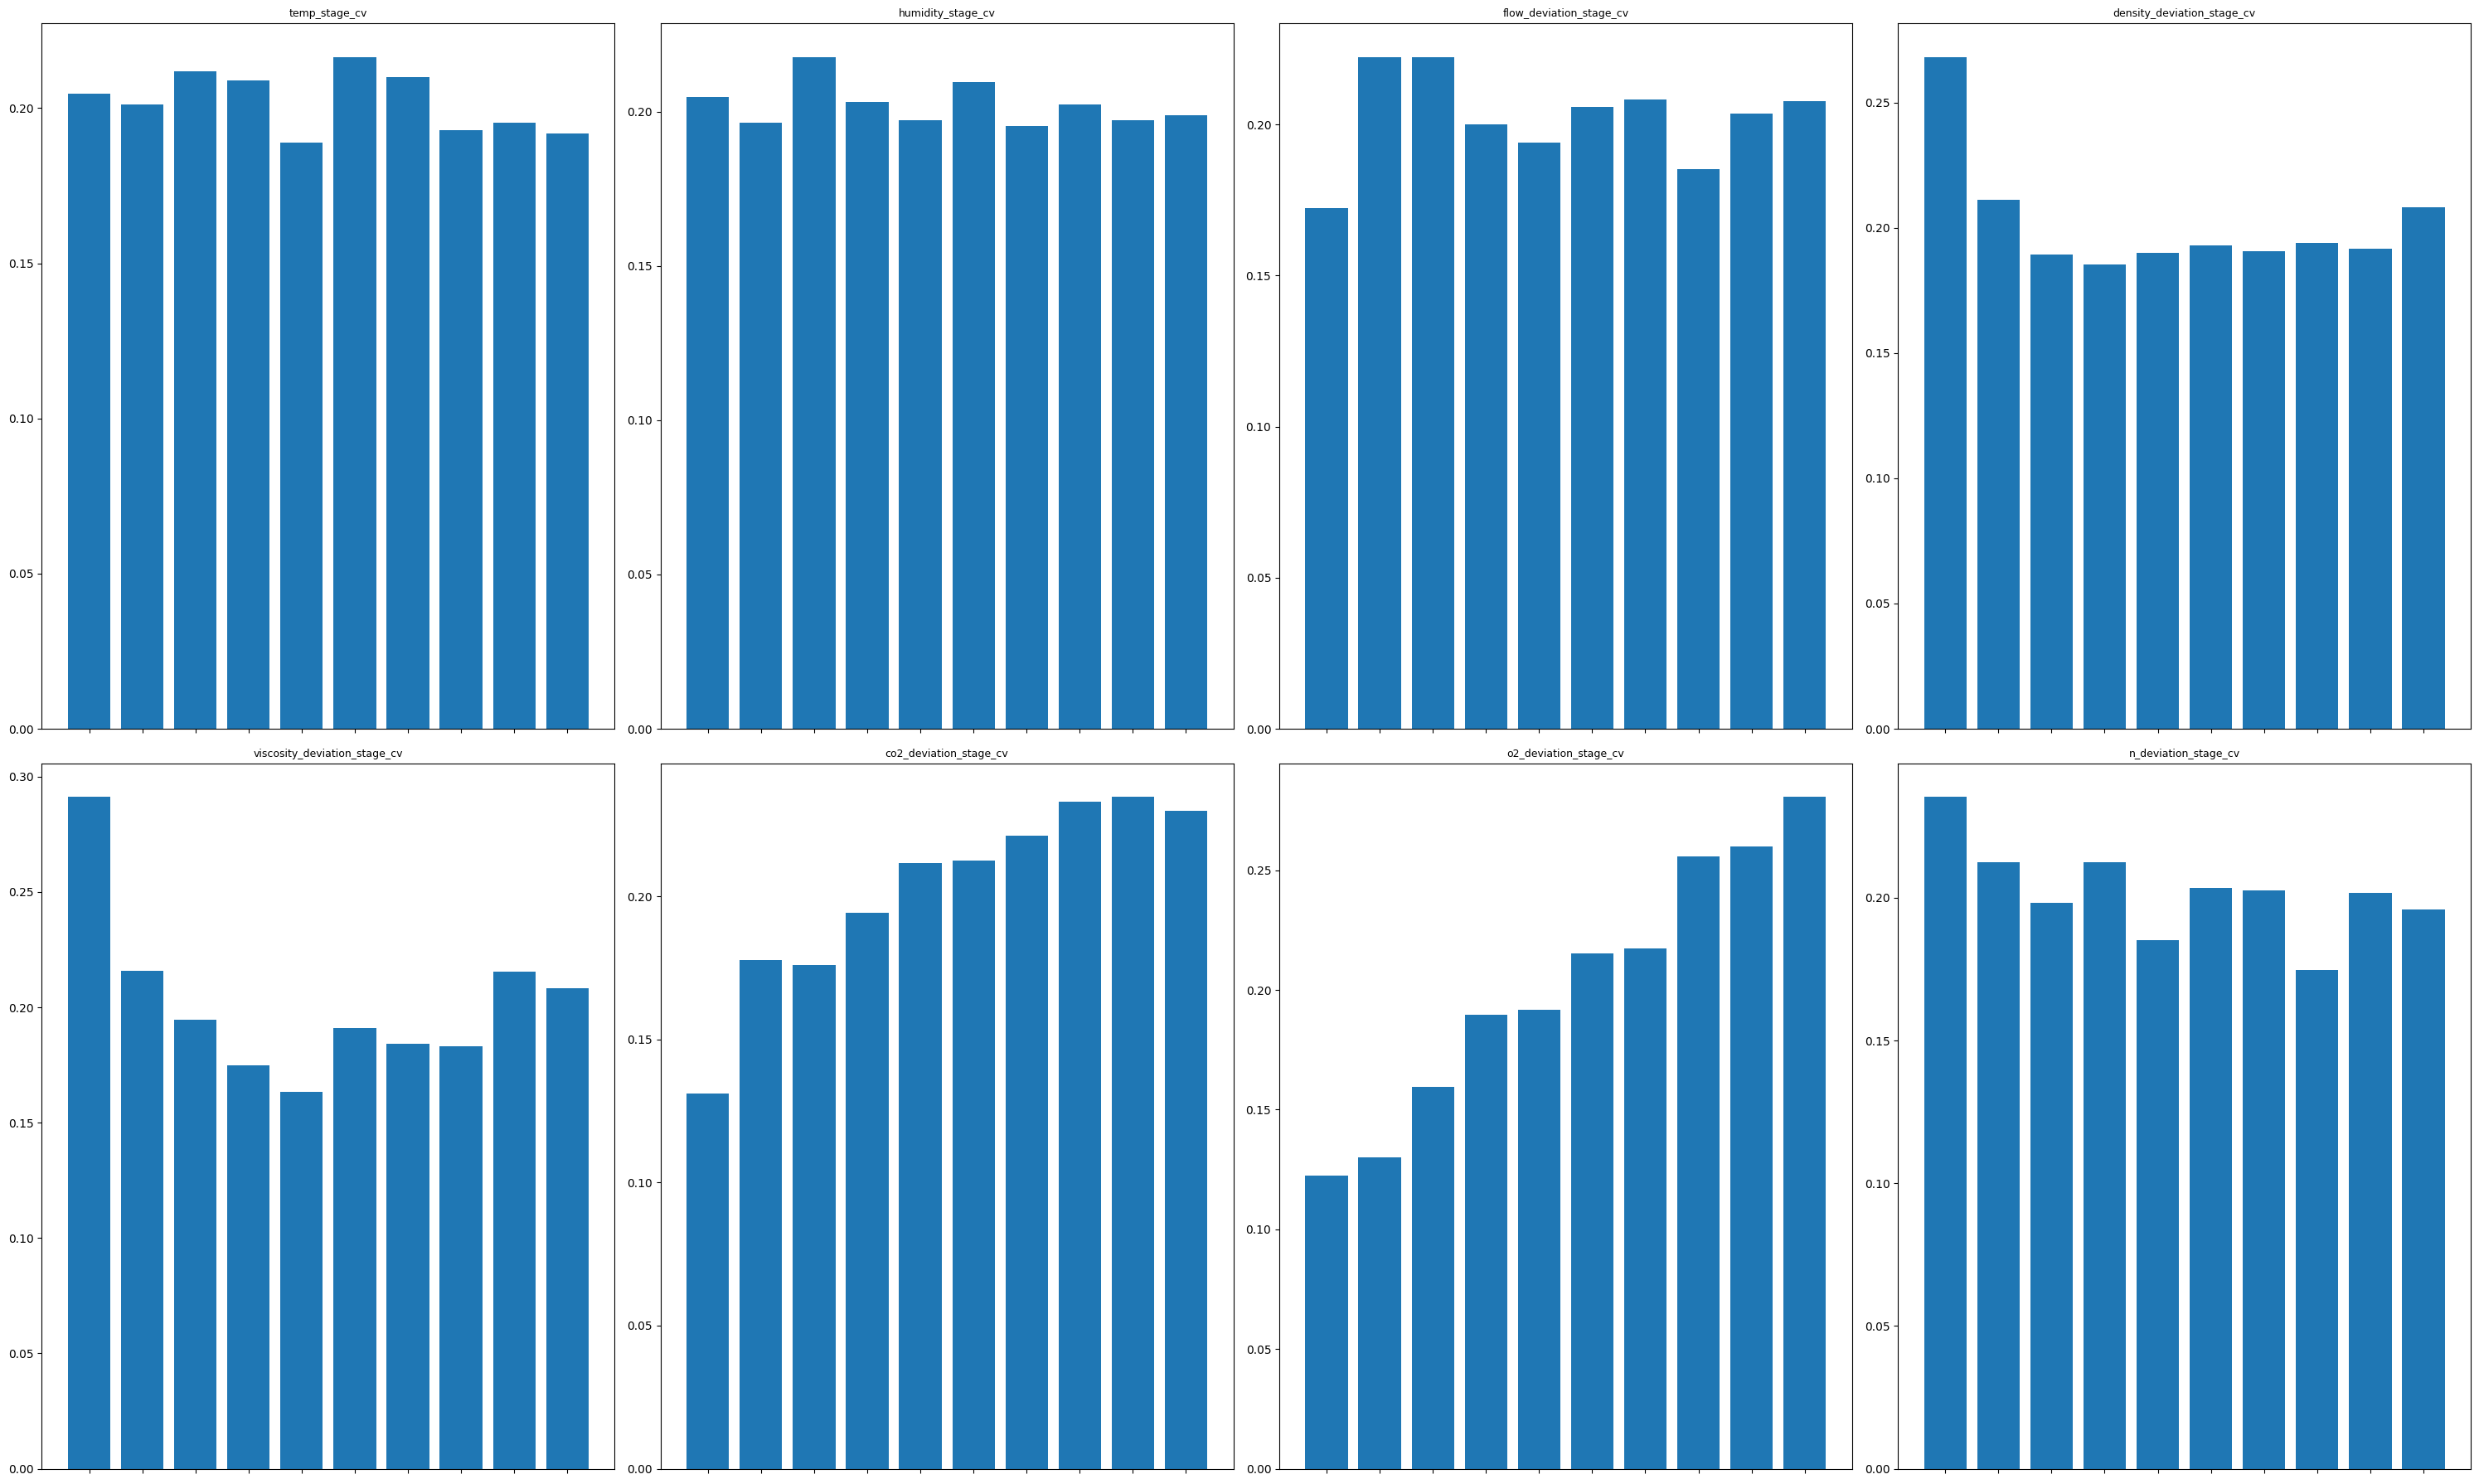

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

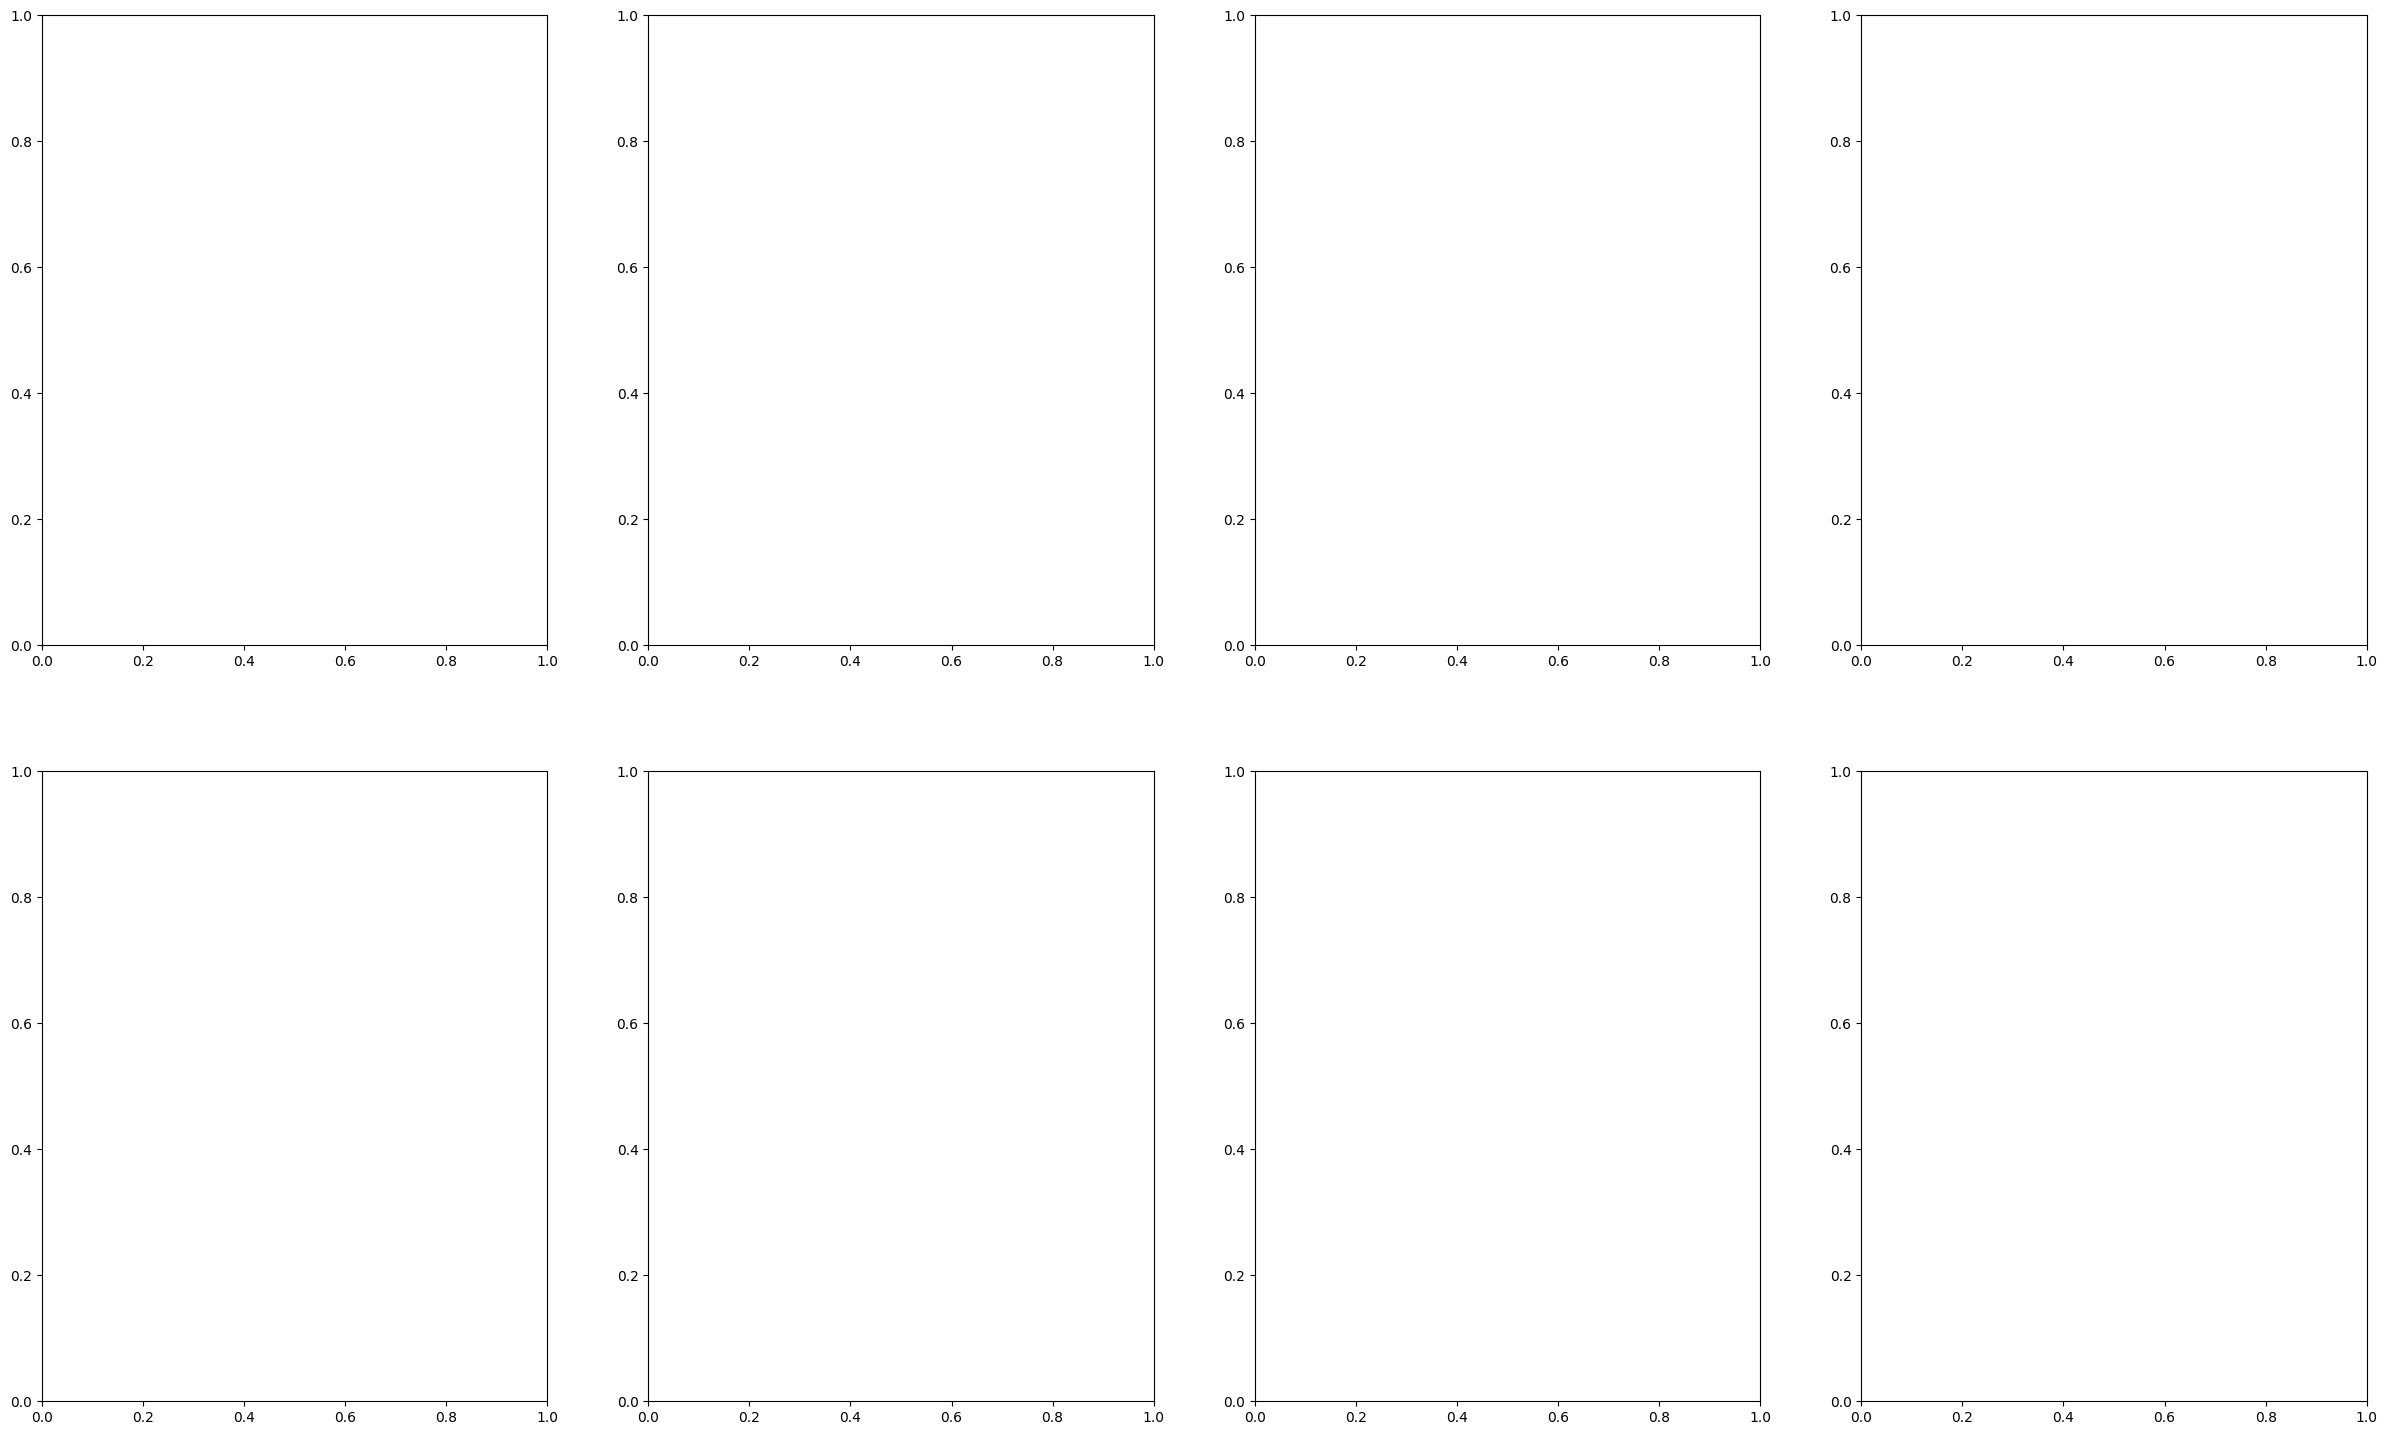

In [ ]:
numeric_cols = df_feat.columns[41:]

cols_per_page = 8  # 5x6 = 30

for start in range(0, len(numeric_cols), cols_per_page):
    subset = numeric_cols[start:start+cols_per_page]

    fig, axes = plt.subplots(2, 4, figsize=(30, 18))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        # 10구간 분할
        df_feat["bin"] = pd.qcut(df_feat[col], q=10, duplicates='drop')

        total = df_feat.groupby("bin")["label"].count()
        defect = df_feat.groupby("bin")["label"].sum()
        defect_ratio = defect / total

        axes[i].bar(range(len(defect_ratio)), defect_ratio)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks(range(len(defect_ratio)))
        axes[i].set_xticklabels([], rotation=45)

    # 남는 subplot 제거
    for j in range(len(subset), 8):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 결함만 묶어서 컬럼별 결함 수

In [ ]:
df_def=df[df['label']==1]
df_def

,stage1_temp,stage2_temp,stage3_temp,stage4_temp,stage5_temp,stage1_humidity,stage2_humidity,stage3_humidity,stage4_humidity,stage5_humidity,...,stage4_co2_deviation,stage4_o2_deviation,stage4_n_deviation,stage5_flow_deviation,stage5_density_deviation,stage5_viscosity_deviation,stage5_co2_deviation,stage5_o2_deviation,stage5_n_deviation,label
0,28.57,30.15,30.71,30.91,31.62,69.08,68.98,70.37,73.67,69.41,...,-0.381981,-0.917519,2.905965,-0.914915,14.642069,-1.124235,2.249968,0.823538,1.574354,1
1,31.74,31.29,30.92,29.52,30.70,68.24,75.97,72.06,69.72,76.11,...,14.243738,-4.937284,0.089265,-4.937284,12.361204,3.886517,3.381750,5.827666,-0.056206,1
5,28.42,28.22,31.63,28.54,31.17,77.29,72.56,76.22,75.59,71.37,...,-10.989594,1.181395,-0.594650,1.181395,-3.064628,0.330088,-2.881577,-1.369120,-0.853303,1
9,31.41,29.68,28.46,28.00,31.86,67.15,72.29,69.02,67.59,71.86,...,-7.492584,0.114533,0.097059,0.114533,5.712956,0.380653,-1.747833,-0.738456,4.059192,1
15,30.28,28.67,31.28,29.90,28.85,68.58,67.02,75.29,72.55,75.73,...,-9.226330,-0.021160,-0.684181,-0.021160,-2.966481,-2.327863,-3.241504,2.416668,-1.223462,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16981,28.25,30.40,31.47,31.19,31.30,77.97,69.04,71.07,78.92,73.56,...,-6.512174,-0.290072,0.611340,-0.290072,-3.277221,0.802519,-1.169797,2.380672,1.927042,1
16983,31.10,28.21,29.48,29.99,28.94,67.13,70.26,78.02,70.84,67.87,...,-7.135756,-4.628364,0.401806,-4.628364,-2.903338,1.884967,-2.287282,1.991928,-1.071761,1
16984,29.04,30.31,28.08,28.18,29.72,72.37,78.94,69.00,72.50,75.81,...,-26.881570,4.974760,0.874596,4.974760,-4.551871,-3.421199,-8.501789,-6.211931,1.445430,1
16994,30.24,28.95,28.87,28.94,29.23,76.02,71.39,68.73,70.77,69.52,...,-1.139003,2.228396,0.044608,2.228396,5.861357,0.414884,-1.108650,-0.813562,1.744824,1


In [ ]:
numeric_cols = df_def.select_dtypes(include="number").columns.tolist()
numeric_cols.remove("label")


for col in numeric_cols:
    plt.figure(figsize=(8,4))

    bins = pd.cut(df_def[col], bins=20)
    bin_count = bins.value_counts().sort_index()

    bin_count.plot(kind="bar")
    plt.title(f"{col} - Defect Count (10 bins)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

NameError: name 'df_def' is not defined

C:\Users\jsuai\AppData\Local\Temp\ipykernel_17840\2151814896.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df.groupby("bin")["label"].count()
C:\Users\jsuai\AppData\Local\Temp\ipykernel_17840\2151814896.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect = df.groupby("bin")["label"].sum()


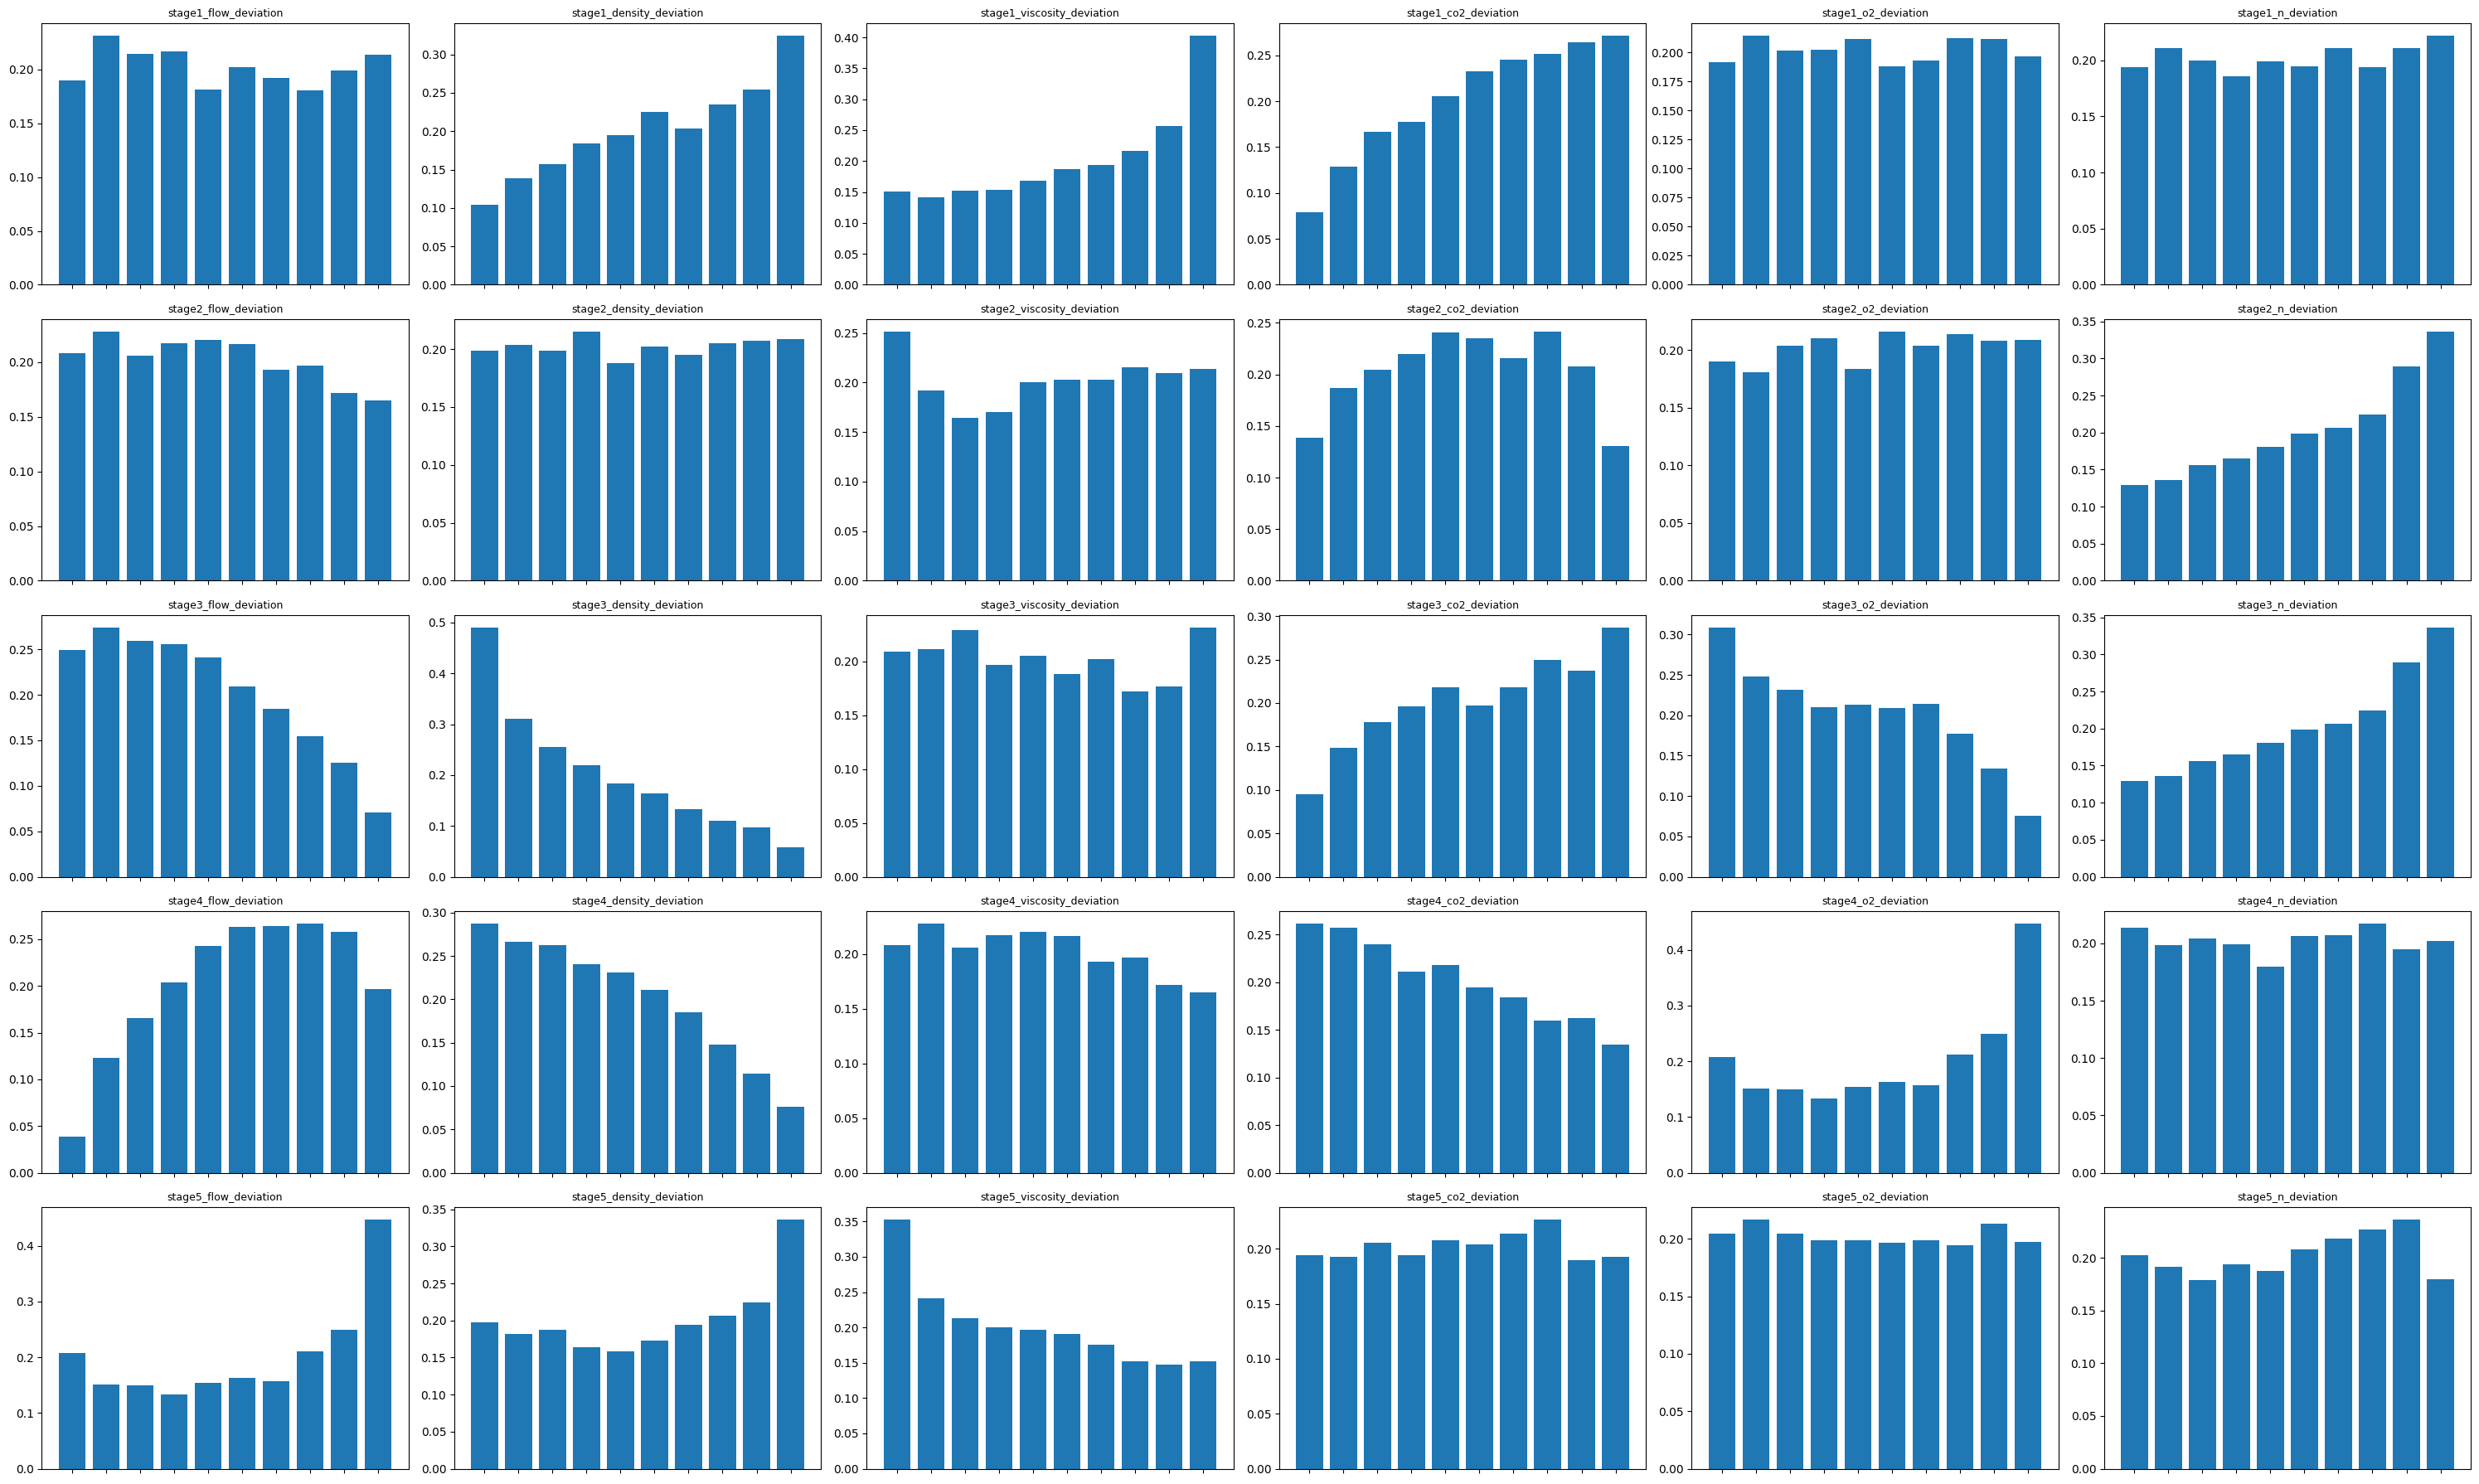

In [ ]:

numeric_cols = cols[10:40]

cols_per_page = 30  # 5x6 = 30

for start in range(0, len(numeric_cols), cols_per_page):
    subset = numeric_cols[start:start+cols_per_page]

    fig, axes = plt.subplots(5, 6, figsize=(30, 18))
    axes = axes.flatten()

    for i, col in enumerate(subset):
        # 10구간 분할
        df["bin"] = pd.qcut(df[col], q=10)

        total = df.groupby("bin")["label"].count()
        defect = df.groupby("bin")["label"].sum()
        defect_ratio = defect / total

        axes[i].bar(range(len(defect_ratio)), defect_ratio)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks(range(len(defect_ratio)))
        axes[i].set_xticklabels([], rotation=45)

    # 남는 subplot 제거
    for j in range(len(subset), 30):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()